# Pipeline Petrofísico Blindado — Single Well QC até Export Parquet

Este notebook implementa um pipeline completo, passo a passo, para análise e preparação de **um único poço LAS**, preferencialmente com curva **DTS**.

## Objetivo

Sair do LAS bruto e chegar em um Parquet limpo, padronizado, auditável e pronto para analytics avançado, rock physics e fases futuras com FEniCS.

## Escopo implementado

1. Load LAS  
2. Header / Metadata QC  
3. Curve Inventory  
4. Depth QC  
5. Unit QC  
6. Raw Data Overview  
7. Standardization  
8. Invalid Values  
9. Null Analysis  
10. Duplicates  
11. Physical Range QC  
12. Outlier Investigation  
13. Geological Consistency Check  
14. Feature Engineering  
15. Depth Alignment / Resampling  
16. Export to Parquet  

## Filosofia do pipeline

Este notebook não remove dados de forma burra.

A regra principal é:

> **dado suspeito deve ser investigado antes de ser removido.**

Em petrofísica, um valor estranho pode ser:
- erro de ferramenta;
- problema de unidade;
- valor inválido não tratado;
- washout;
- gás;
- fratura;
- mudança litológica;
- zona de transição;
- formação pouco compactada;
- fenômeno físico real.

Por isso, o pipeline cria flags, gráficos, relatórios de QC e somente depois gera um dataset processado.

In [1]:
# ============================================================
# STEP 0 — ENVIRONMENT SETUP
# ============================================================
#
# Este bloco prepara o ambiente do notebook.
#
# A ideia aqui é carregar bibliotecas fundamentais para:
# - leitura de arquivos LAS com lasio;
# - manipulação forte com pandas;
# - operações vetoriais com numpy;
# - visualizações com matplotlib e seaborn;
# - criação de relatórios tabulares de QC;
# - exportação final para Parquet.
#
# Observação:
# Este notebook foi feito para rodar em ambiente local.
# Ajuste DATA_DIR para apontar para a pasta onde estão seus arquivos .las.

from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple
import warnings

import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Configurações globais do pandas
# ------------------------------------------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


# ------------------------------------------------------------
# Configurações globais dos gráficos
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


# ------------------------------------------------------------
# Evita poluição visual com warnings repetitivos.
# Mas não elimina warnings críticos de erro.
# ------------------------------------------------------------
warnings.filterwarnings("ignore", category=UserWarning)


# ------------------------------------------------------------
# Diretórios do projeto
# ------------------------------------------------------------
DATA_DIR = Path("../data/las")
OUTPUT_DIR = Path("../data/parquet/processed")
REPORT_DIR = Path("../reports/single_well_qc")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Seleção do poço
# ------------------------------------------------------------
# Se WELL_NAME = None, o notebook tenta escolher automaticamente
# o melhor poço com DTS disponível.
#
# Se quiser forçar um poço específico, use algo como:
# WELL_NAME = "TFT-2"
#
WELL_NAME: Optional[str] = None


print("Ambiente preparado com sucesso.")
print(f"DATA_DIR   = {DATA_DIR.resolve()}")
print(f"OUTPUT_DIR = {OUTPUT_DIR.resolve()}")
print(f"REPORT_DIR = {REPORT_DIR.resolve()}")

Ambiente preparado com sucesso.
DATA_DIR   = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/las
OUTPUT_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/data/parquet/processed
REPORT_DIR = /home/wolf/Documentos/desenvolvimento/data-science-freestyle/wolf-petrophysics-analitics/reports/single_well_qc


# STEP 1 — Load LAS

Nesta etapa, o notebook localiza os arquivos `.las`, lê os headers e escolhe **um único poço** para o pipeline.

A preferência será por poços com curva **DTS**, porque DTS é essencial para cálculos futuros envolvendo:
- Vs;
- propriedades elásticas;
- geomecânica;
- rock physics;
- integração futura com FEniCS.

A seleção automática não deve ser vista como verdade absoluta. Ela apenas ajuda a escolher um bom candidato inicial.

In [2]:
# ============================================================
# STEP 1 — LOAD LAS
# ============================================================

def list_las_files(data_dir: Path) -> List[Path]:
    """
    Lista arquivos LAS dentro de uma pasta.

    Por que isso existe?
    --------------------
    Em projetos reais, nunca devemos assumir que os arquivos existem.
    Primeiro validamos a pasta, depois validamos a presença dos arquivos.

    Retorno
    -------
    Lista ordenada de caminhos .las.
    """
    if not data_dir.exists():
        raise FileNotFoundError(f"A pasta não existe: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.las"))

    if not files:
        raise FileNotFoundError(f"Nenhum arquivo .las encontrado em: {data_dir.resolve()}")

    return files


def safe_read_las(file_path: Path) -> lasio.LASFile:
    """
    Lê um LAS de forma centralizada.

    Por que centralizar?
    --------------------
    Porque se no futuro precisarmos lidar com encoding, curvas duplicadas,
    warnings específicos ou arquivos problemáticos, alteramos em um único ponto.
    """
    try:
        return lasio.read(str(file_path))
    except Exception as exc:
        raise RuntimeError(f"Erro lendo LAS: {file_path.name}") from exc


def las_to_dataframe(las: lasio.LASFile) -> pd.DataFrame:
    """
    Converte LAS para DataFrame pandas.

    Importante:
    -----------
    las.df() normalmente coloca a profundidade como índice.
    Aqui usamos reset_index() para transformar a profundidade em coluna,
    facilitando validações, gráficos, filtros e exportação.
    """
    df = las.df().reset_index()

    # Padronização inicial simples: nomes em uppercase e sem espaços.
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
    )

    return df


las_files = list_las_files(DATA_DIR)

print(f"Total de arquivos LAS encontrados: {len(las_files)}")
print("Primeiros arquivos encontrados:")
display(pd.DataFrame({"las_file": [p.name for p in las_files[:20]]}))

Total de arquivos LAS encontrados: 83
Primeiros arquivos encontrados:


,las_file
0,AAM-1.las
1,AAM-10.las
2,AAM-12.las
3,AAM-13.las
4,AAM-14.las
5,AAM-16.las
6,AAM-17.las
7,AAM-18.las
8,AAM-19.las
9,AAM-2.las


In [3]:
# ============================================================
# STEP 1.1 — INVENTÁRIO RÁPIDO PARA ESCOLHER POÇO COM DTS
# ============================================================

def get_curve_names(las: lasio.LASFile) -> List[str]:
    """
    Retorna os nomes das curvas do LAS em uppercase.

    Isso permite descobrir rapidamente quais poços possuem DTS,
    DTC, RHOB e outras curvas essenciais.
    """
    return [curve.mnemonic.upper().strip() for curve in las.curves]


def summarize_las_file(file_path: Path) -> Dict[str, object]:
    """
    Cria um resumo leve do LAS.

    O objetivo é escolher um poço candidato sem ainda mergulhar
    no QC completo.
    """
    las = safe_read_las(file_path)
    curves = get_curve_names(las)

    well_name = file_path.stem

    try:
        df_tmp = las_to_dataframe(las)
        n_rows = len(df_tmp)

        # Avalia presença e preenchimento de curvas importantes.
        # Aqui usamos pandas/numpy com força:
        # - reindex para garantir que todas as curvas existam no relatório;
        # - notna().mean() para calcular percentual preenchido de forma vetorizada.
        important_curves = ["DTC", "DTS", "RHOB", "NPHI", "GR", "RDEP", "RMED", "CALI", "BS"]
        fill_rates = (
            df_tmp.reindex(columns=important_curves)
            .notna()
            .mean()
            .rename(lambda c: f"{c}_FILL_RATE")
            .to_dict()
        )

    except Exception:
        n_rows = np.nan
        fill_rates = {}

    return {
        "WELL": well_name,
        "FILE": file_path.name,
        "N_CURVES": len(curves),
        "N_ROWS": n_rows,
        "HAS_DTS": "DTS" in curves,
        "HAS_DTC": "DTC" in curves,
        "HAS_RHOB": "RHOB" in curves,
        "HAS_GR": "GR" in curves,
        "CURVES": ", ".join(curves),
        **fill_rates,
    }


inventory_df = pd.DataFrame([summarize_las_file(path) for path in las_files])

# Score simples para escolher um bom poço:
# DTS pesa muito, depois DTC/RHOB/GR/RDEP e volume de dados.
score_columns = ["DTS_FILL_RATE", "DTC_FILL_RATE", "RHOB_FILL_RATE", "GR_FILL_RATE", "RDEP_FILL_RATE"]
for col in score_columns:
    if col not in inventory_df.columns:
        inventory_df[col] = 0.0

inventory_df["SELECTION_SCORE"] = (
    inventory_df["DTS_FILL_RATE"].fillna(0) * 5.0
    + inventory_df["DTC_FILL_RATE"].fillna(0) * 2.0
    + inventory_df["RHOB_FILL_RATE"].fillna(0) * 2.0
    + inventory_df["GR_FILL_RATE"].fillna(0) * 1.0
    + inventory_df["RDEP_FILL_RATE"].fillna(0) * 1.0
)

inventory_ranked = inventory_df.sort_values(
    ["HAS_DTS", "SELECTION_SCORE", "N_ROWS"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(
    inventory_ranked[
        ["WELL", "FILE", "N_ROWS", "N_CURVES", "HAS_DTS", "DTS_FILL_RATE",
         "DTC_FILL_RATE", "RHOB_FILL_RATE", "GR_FILL_RATE", "RDEP_FILL_RATE", "SELECTION_SCORE"]
    ].head(20)
)

# Salva inventário para auditoria.
inventory_path = REPORT_DIR / "las_inventory_selection_candidates.csv"
inventory_ranked.to_csv(inventory_path, index=False)
print(f"Inventário salvo em: {inventory_path}")

,WELL,FILE,N_ROWS,N_CURVES,HAS_DTS,DTS_FILL_RATE,DTC_FILL_RATE,RHOB_FILL_RATE,GR_FILL_RATE,RDEP_FILL_RATE,SELECTION_SCORE
0,TFT-4,TFT-4.las,18731,20,True,0.814265,0.971598,0.416422,0.996530,0.991244,8.835140
1,AAM-17,AAM-17.las,15388,21,True,0.787562,0.790876,0.535937,0.967897,0.975630,8.534962
2,ALR-11,ALR-11.las,24803,21,True,0.851832,0.859090,0.210378,0.998549,0.999194,8.395839
3,ALR-3,ALR-3.las,18710,22,True,0.684233,0.687921,0.693373,0.998450,0.998022,8.180224
4,ALR-2,ALR-2.las,16967,21,True,0.684741,0.684741,0.670773,0.994401,0.996876,8.126009
5,ISL-8,ISL-8.las,28434,22,True,0.596645,0.993353,0.343532,0.996835,0.997503,7.651333
6,ALR-13,ALR-13.las,21948,20,True,0.607345,0.607254,0.604019,0.998679,0.997950,7.455896
7,ISL-14,ISL-14.las,26343,20,True,0.518658,0.810880,0.557567,0.999393,0.982386,7.311961
8,TFT-3,TFT-3.las,24730,23,True,0.470926,0.741407,0.730651,0.976668,0.993328,7.268742
9,HR-16,HR-16.las,17304,24,True,0.591771,0.610321,0.608530,0.923659,0.933830,7.254045


Inventário salvo em: ../reports/single_well_qc/las_inventory_selection_candidates.csv


In [4]:
# ============================================================
# STEP 1.2 — DEFINIÇÃO DO POÇO ALVO
# ============================================================

if WELL_NAME is None:
    selected_row = inventory_ranked.iloc[0]
    WELL_NAME = str(selected_row["WELL"])
    print(f"Poço escolhido automaticamente: {WELL_NAME}")
else:
    print(f"Poço definido manualmente: {WELL_NAME}")


selected_file_candidates = [p for p in las_files if p.stem.upper() == WELL_NAME.upper()]
if not selected_file_candidates:
    raise FileNotFoundError(f"Não encontrei arquivo LAS para WELL_NAME={WELL_NAME}")

selected_file = selected_file_candidates[0]

las = safe_read_las(selected_file)
raw_df = las_to_dataframe(las)

# Adiciona identificação do poço.
raw_df["WELL"] = WELL_NAME

print(f"Arquivo selecionado: {selected_file.name}")
print(f"Shape bruto: {raw_df.shape}")
display(raw_df.head())
display(raw_df.tail())

Poço escolhido automaticamente: TFT-4
Arquivo selecionado: TFT-4.las
Shape bruto: (18731, 21)


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
0,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
1,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
2,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
3,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
4,372.616400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
18726,"3,218.360400",NaN,NaN,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18727,"3,218.512400",NaN,NaN,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18728,"3,218.664400",NaN,NaN,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18729,"3,218.816400",NaN,NaN,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18730,"3,218.968400",NaN,NaN,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4


# STEP 2 — Header / Metadata QC

Antes de analisar curva, precisamos entender o **contexto do LAS**.

O header pode revelar:
- profundidade inicial/final;
- step declarado;
- valor nulo oficial;
- unidade da profundidade;
- nome do poço;
- campo;
- empresa;
- data;
- serviço;
- inconsistências entre metadata e dados reais.

Essa etapa é muito importante porque muitos problemas aparecem antes mesmo de olhar os logs.

In [5]:
# ============================================================
# STEP 2 — HEADER / METADATA QC
# ============================================================

def header_section_to_dataframe(las: lasio.LASFile, section_name: str) -> pd.DataFrame:
    """
    Converte uma seção do header LAS em DataFrame.

    Seções comuns:
    - Version
    - Well
    - Curves
    - Parameter

    Por que DataFrame?
    ------------------
    Porque fica mais fácil filtrar, ordenar, visualizar, salvar e comparar.
    """
    rows = []

    try:
        section = las.header[section_name]
    except KeyError:
        return pd.DataFrame(columns=["SECTION", "MNEMONIC", "UNIT", "VALUE", "DESCRIPTION"])

    for item in section:
        rows.append({
            "SECTION": section_name,
            "MNEMONIC": str(getattr(item, "mnemonic", "")).strip(),
            "UNIT": str(getattr(item, "unit", "")).strip(),
            "VALUE": getattr(item, "value", ""),
            "DESCRIPTION": str(getattr(item, "descr", "")).strip(),
        })

    return pd.DataFrame(rows)


version_header_df = header_section_to_dataframe(las, "Version")
well_header_df = header_section_to_dataframe(las, "Well")
curve_header_df = header_section_to_dataframe(las, "Curves")
parameter_header_df = header_section_to_dataframe(las, "Parameter")

print("Header — Version")
display(version_header_df)

print("Header — Well")
display(well_header_df)

print("Header — Curves")
display(curve_header_df)

print("Header — Parameter")
display(parameter_header_df)

Header — Version


,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Version,VERS,,2.000000,
1,Version,WRAP,,NO,


Header — Well


,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Well,STRT,m,372.008400,
1,Well,STOP,m,"3,218.992700",
2,Well,STEP,m,0.152000,
3,Well,NULL,,-999.250000,
4,Well,COMP,,SONATRACH,COMPANY
5,Well,WELL,,TFT-4,WELL
6,Well,FLD,,Tin Fouye Tabankort,FIELD
7,Well,LOC,,"Algeria, Lat: 26.406, Lon: 5.556",LOCATION
8,Well,SRVC,,Weatherford,SERVICE COMPANY
9,Well,DATE,,2018-12-06 00:00:00 : Log Export Date {yyyy-...,ss}


Header — Curves


,SECTION,MNEMONIC,UNIT,VALUE,DESCRIPTION
0,Curves,DEPT,m,,DEPTH
1,Curves,LITHOLOGY_CONFIDENCE,_,,LITHOLOGY_CONFIDENCE
2,Curves,LITHOLOGY_CLASS,_,,LITHOLOGY_CLASS
3,Curves,CALI,in,,CALI
4,Curves,BS,in,,BS
5,Curves,ROPA,_,,ROPA
6,Curves,ROP,m/h,,ROP
7,Curves,RDEP,ohm.m,,RDEP
8,Curves,RMED,ohm.m,,RMED
9,Curves,DTS,us/ft,,DTS


Header — Parameter


""


In [6]:
# ============================================================
# STEP 2.1 — EXTRAÇÃO DE METADADOS IMPORTANTES
# ============================================================

def get_header_value(header_df: pd.DataFrame, mnemonic: str, default=np.nan):
    """
    Busca um valor do header pelo mnemonic.

    Exemplo:
    - STRT
    - STOP
    - STEP
    - NULL
    - WELL
    - FLD
    """
    mask = header_df["MNEMONIC"].str.upper().eq(mnemonic.upper())
    if not mask.any():
        return default
    return header_df.loc[mask, "VALUE"].iloc[0]


metadata = {
    "WELL_NAME_FROM_FILE": WELL_NAME,
    "WELL_NAME_FROM_HEADER": get_header_value(well_header_df, "WELL"),
    "FIELD": get_header_value(well_header_df, "FLD"),
    "COMPANY": get_header_value(well_header_df, "COMP"),
    "SERVICE_COMPANY": get_header_value(well_header_df, "SRVC"),
    "DATE": get_header_value(well_header_df, "DATE"),
    "STRT": get_header_value(well_header_df, "STRT"),
    "STOP": get_header_value(well_header_df, "STOP"),
    "STEP": get_header_value(well_header_df, "STEP"),
    "NULL": get_header_value(well_header_df, "NULL"),
}

metadata_df = pd.DataFrame([metadata]).T.rename(columns={0: "VALUE"})
display(metadata_df)

metadata_path = REPORT_DIR / f"{WELL_NAME}_metadata.csv"
metadata_df.to_csv(metadata_path)
print(f"Metadata salvo em: {metadata_path}")

,VALUE
WELL_NAME_FROM_FILE,TFT-4
WELL_NAME_FROM_HEADER,TFT-4
FIELD,Tin Fouye Tabankort
COMPANY,SONATRACH
SERVICE_COMPANY,Weatherford
DATE,2018-12-06 00:00:00 : Log Export Date {yyyy-...
STRT,372.008400
STOP,"3,218.992700"
STEP,0.152000
NULL,-999.250000


Metadata salvo em: ../reports/single_well_qc/TFT-4_metadata.csv


# STEP 3 — Curve Inventory

Agora vamos fazer o inventário detalhado das curvas do poço selecionado.

Perguntas que esta etapa responde:

- Quais curvas existem?
- Quais unidades foram declaradas?
- Quantos valores válidos cada curva possui?
- Qual o percentual de preenchimento?
- DTS existe mesmo?
- DTC, RHOB e GR estão disponíveis?
- Quais curvas parecem vazias ou quase vazias?

Esse inventário é a primeira visão honesta do potencial do poço.

In [7]:
# ============================================================
# STEP 3 — CURVE INVENTORY
# ============================================================

def build_curve_inventory(df: pd.DataFrame, curve_header_df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria inventário das curvas no DataFrame.

    Usa pandas de forma vetorizada:
    - count para valores não nulos;
    - isna().sum para nulos;
    - mean para taxa de preenchimento;
    - nunique para diversidade de valores;
    - describe complementar depois.
    """
    total_rows = len(df)

    numeric_candidate_cols = [c for c in df.columns if c != "WELL"]

    base = pd.DataFrame({
        "CURVE": numeric_candidate_cols,
        "NON_NULL_COUNT": df[numeric_candidate_cols].notna().sum().values,
        "NULL_COUNT": df[numeric_candidate_cols].isna().sum().values,
        "FILL_RATE": df[numeric_candidate_cols].notna().mean().values,
        "NULL_RATE": df[numeric_candidate_cols].isna().mean().values,
        "UNIQUE_VALUES": df[numeric_candidate_cols].nunique(dropna=True).values,
        "TOTAL_ROWS": total_rows,
    })

    units = (
        curve_header_df[["MNEMONIC", "UNIT", "DESCRIPTION"]]
        .rename(columns={"MNEMONIC": "CURVE"})
        .drop_duplicates(subset=["CURVE"])
    )

    result = (
        base.merge(units, on="CURVE", how="left")
        .sort_values(["FILL_RATE", "CURVE"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return result


curve_inventory_df = build_curve_inventory(raw_df, curve_header_df)

display(curve_inventory_df)

curve_inventory_path = REPORT_DIR / f"{WELL_NAME}_curve_inventory.csv"
curve_inventory_df.to_csv(curve_inventory_path, index=False)
print(f"Inventário de curvas salvo em: {curve_inventory_path}")

,CURVE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE,NULL_RATE,UNIQUE_VALUES,TOTAL_ROWS,UNIT,DESCRIPTION
0,DEPT,18731,0,1.000000,0.000000,18731,18731,m,DEPTH
1,ROPA,18680,51,0.997277,0.002723,18673,18731,_,ROPA
2,BS,18674,57,0.996957,0.003043,5,18731,in,BS
3,GR,18666,65,0.996530,0.003470,18641,18731,gAPI,GR
4,ROP,18664,67,0.996423,0.003577,18626,18731,m/h,ROP
5,DEPTH_MD,18567,164,0.991244,0.008756,18567,18731,_,DEPTH_MD
6,RDEP,18567,164,0.991244,0.008756,18559,18731,ohm.m,RDEP
7,X_LOC,18567,164,0.991244,0.008756,8708,18731,_,x_loc
8,Y_LOC,18567,164,0.991244,0.008756,875,18731,_,y_loc
9,Z_LOC,18567,164,0.991244,0.008756,18567,18731,_,z_loc


Inventário de curvas salvo em: ../reports/single_well_qc/TFT-4_curve_inventory.csv


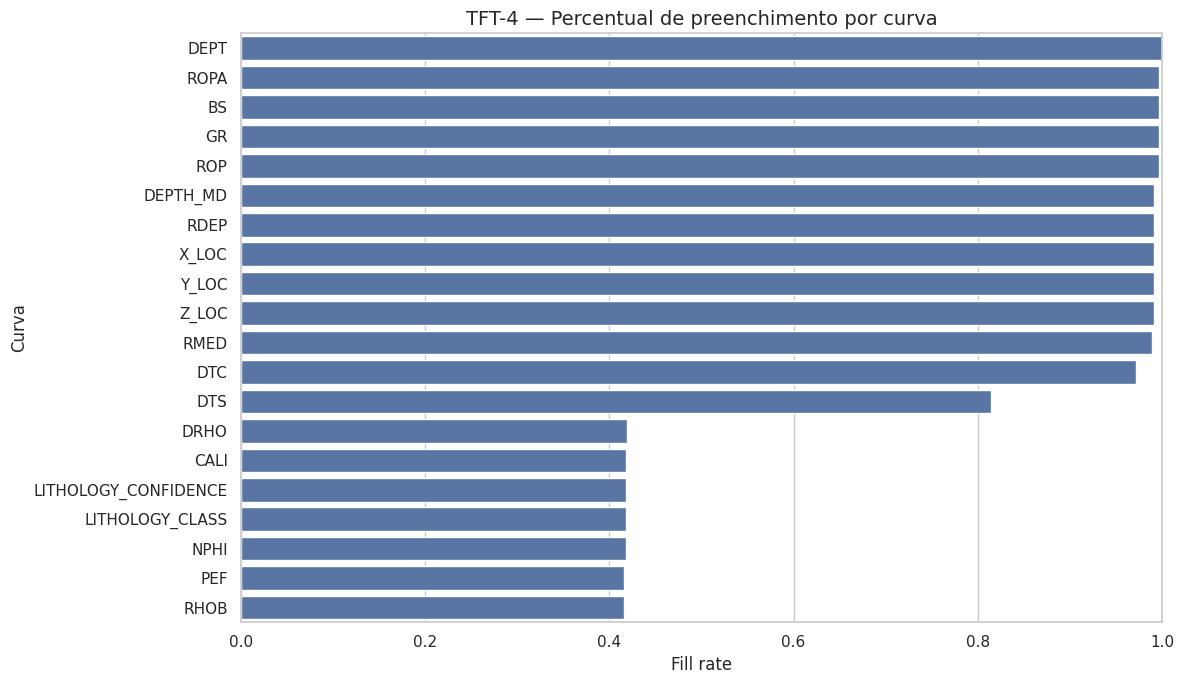

In [8]:
# ============================================================
# STEP 3.1 — VISUALIZAÇÃO DO PREENCHIMENTO DAS CURVAS
# ============================================================

plt.figure(figsize=(12, max(6, len(curve_inventory_df) * 0.35)))
sns.barplot(
    data=curve_inventory_df,
    y="CURVE",
    x="FILL_RATE",
    orient="h"
)
plt.title(f"{WELL_NAME} — Percentual de preenchimento por curva")
plt.xlabel("Fill rate")
plt.ylabel("Curva")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# STEP 4 — Depth QC

A profundidade é o eixo principal de todo perfil de poço.

Se a profundidade estiver ruim, todo o resto fica comprometido:
- gráficos por profundidade;
- resampling;
- correlação entre curvas;
- interpolação;
- exportação;
- simulação física;
- FEniCS.

Nesta etapa verificamos:

- qual coluna representa profundidade;
- se a profundidade é crescente;
- se existem duplicatas;
- se o step é constante;
- se existem gaps;
- se existem saltos anormais.

In [9]:
# ============================================================
# STEP 4 — DEPTH QC
# ============================================================

DEPTH_CANDIDATES = ["DEPTH", "DEPT", "DEPTH_MD", "MD"]

def detect_depth_column(df: pd.DataFrame) -> str:
    """
    Detecta a coluna de profundidade mais provável.

    Por que isso é necessário?
    --------------------------
    Arquivos LAS podem trazer DEPT, DEPTH_MD, MD ou outras variações.
    O pipeline precisa funcionar com diferentes convenções.
    """
    existing = [c for c in DEPTH_CANDIDATES if c in df.columns]

    if not existing:
        raise ValueError(f"Nenhuma coluna de profundidade encontrada. Candidatas: {DEPTH_CANDIDATES}")

    # Preferência:
    # 1) DEPT costuma vir do índice LAS original;
    # 2) DEPTH_MD é comum em datasets petrofísicos;
    # 3) DEPTH/MD como alternativas.
    for preferred in ["DEPT", "DEPTH_MD", "DEPTH", "MD"]:
        if preferred in existing:
            return preferred

    return existing[0]


depth_col_raw = detect_depth_column(raw_df)
print(f"Coluna de profundidade detectada: {depth_col_raw}")


depth_series = pd.to_numeric(raw_df[depth_col_raw], errors="coerce")
depth_diff = depth_series.diff()

depth_qc = {
    "DEPTH_COLUMN": depth_col_raw,
    "N_ROWS": len(raw_df),
    "DEPTH_NON_NULL": depth_series.notna().sum(),
    "DEPTH_NULL": depth_series.isna().sum(),
    "DEPTH_MIN": depth_series.min(),
    "DEPTH_MAX": depth_series.max(),
    "DEPTH_RANGE": depth_series.max() - depth_series.min(),
    "IS_MONOTONIC_INCREASING": depth_series.is_monotonic_increasing,
    "DUPLICATED_DEPTH_COUNT": depth_series.duplicated().sum(),
    "NEGATIVE_OR_ZERO_STEPS": (depth_diff <= 0).sum(),
    "MEDIAN_STEP": depth_diff[depth_diff > 0].median(),
    "MEAN_STEP": depth_diff[depth_diff > 0].mean(),
    "MIN_POSITIVE_STEP": depth_diff[depth_diff > 0].min(),
    "MAX_POSITIVE_STEP": depth_diff[depth_diff > 0].max(),
    "STEP_STD": depth_diff[depth_diff > 0].std(),
}

depth_qc_df = pd.DataFrame([depth_qc]).T.rename(columns={0: "VALUE"})
display(depth_qc_df)

depth_qc_path = REPORT_DIR / f"{WELL_NAME}_depth_qc.csv"
depth_qc_df.to_csv(depth_qc_path)
print(f"Depth QC salvo em: {depth_qc_path}")

Coluna de profundidade detectada: DEPT


,VALUE
DEPTH_COLUMN,DEPT
N_ROWS,18731
DEPTH_NON_NULL,18731
DEPTH_NULL,0
DEPTH_MIN,372.008400
DEPTH_MAX,"3,218.968400"
DEPTH_RANGE,"2,846.960000"
IS_MONOTONIC_INCREASING,True
DUPLICATED_DEPTH_COUNT,0
NEGATIVE_OR_ZERO_STEPS,0


Depth QC salvo em: ../reports/single_well_qc/TFT-4_depth_qc.csv


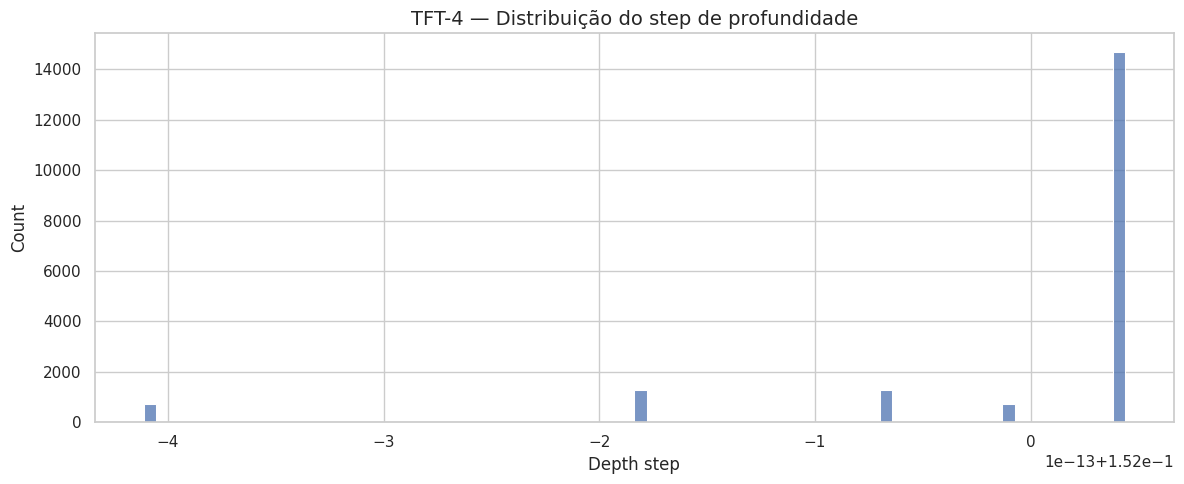

Step mediano: 0.15200000000004366
Threshold para gap: 0.45600000000013097
Total de gaps detectados: 0


,DEPT,PREVIOUS_DEPTH,CURRENT_DEPTH,GAP_SIZE


Gaps salvos em: ../reports/single_well_qc/TFT-4_depth_gaps.csv


In [10]:
# ============================================================
# STEP 4.1 — ANÁLISE DOS STEPS DE PROFUNDIDADE
# ============================================================

positive_steps = depth_diff[depth_diff > 0].dropna()

plt.figure(figsize=(12, 5))
sns.histplot(positive_steps, bins=80)
plt.title(f"{WELL_NAME} — Distribuição do step de profundidade")
plt.xlabel("Depth step")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Gaps são definidos aqui como passos muito maiores que o step mediano.
# Este limite é conservador e pode ser ajustado.
median_step = positive_steps.median()
gap_threshold = median_step * 3

gap_mask = depth_diff > gap_threshold
gaps_df = raw_df.loc[gap_mask, [depth_col_raw]].copy()
gaps_df["PREVIOUS_DEPTH"] = depth_series.shift(1).loc[gap_mask].values
gaps_df["CURRENT_DEPTH"] = depth_series.loc[gap_mask].values
gaps_df["GAP_SIZE"] = depth_diff.loc[gap_mask].values

print(f"Step mediano: {median_step}")
print(f"Threshold para gap: {gap_threshold}")
print(f"Total de gaps detectados: {len(gaps_df)}")

display(gaps_df.head(50))

gaps_path = REPORT_DIR / f"{WELL_NAME}_depth_gaps.csv"
gaps_df.to_csv(gaps_path, index=False)
print(f"Gaps salvos em: {gaps_path}")

# STEP 5 — Unit QC

Agora validamos as unidades declaradas.

Isto é fundamental porque os cálculos futuros dependem diretamente das unidades.

Exemplos críticos:

- DTC e DTS geralmente vêm em `us/ft`;
- RHOB geralmente vem em `g/cm3`;
- GR geralmente vem em `gAPI`;
- RDEP/RMED/RSHA geralmente vêm em `ohm.m`;
- profundidade pode vir em metro ou pé.

Se as unidades estiverem erradas ou misturadas, os atributos derivados ficarão errados.

In [11]:
# ============================================================
# STEP 5 — UNIT QC
# ============================================================

# Unidades esperadas por curva.
# Isso não é uma verdade universal, mas uma referência de QC.
EXPECTED_UNITS = {
    "DEPTH": ["m", "meter", "meters", "ft", "feet", ""],
    "DEPT": ["m", "meter", "meters", "ft", "feet", ""],
    "DEPTH_MD": ["m", "meter", "meters", "ft", "feet", ""],
    "GR": ["gapi", "api", "gAPI".lower(), ""],
    "RHOB": ["g/cm3", "g/cm³", "g/cc", ""],
    "DTC": ["us/ft", "µs/ft", "usec/ft", ""],
    "DTS": ["us/ft", "µs/ft", "usec/ft", ""],
    "NPHI": ["m3/m3", "v/v", "frac", ""],
    "RDEP": ["ohm.m", "ohmm", "ohm-m", ""],
    "RMED": ["ohm.m", "ohmm", "ohm-m", ""],
    "RSHA": ["ohm.m", "ohmm", "ohm-m", ""],
    "CALI": ["in", "inch", "inches", ""],
    "BS": ["in", "inch", "inches", ""],
}


def normalize_unit(unit: object) -> str:
    """
    Normaliza unidade para comparação textual simples.

    Remove espaços e coloca em lowercase.
    """
    if pd.isna(unit):
        return ""
    return str(unit).strip().lower().replace(" ", "")


unit_qc_df = curve_inventory_df[["CURVE", "UNIT", "DESCRIPTION"]].copy()
unit_qc_df["UNIT_NORMALIZED"] = unit_qc_df["UNIT"].map(normalize_unit)

def unit_status(row: pd.Series) -> str:
    curve = row["CURVE"]
    unit = row["UNIT_NORMALIZED"]

    expected = EXPECTED_UNITS.get(curve)
    if expected is None:
        return "NO_RULE"

    expected_norm = [normalize_unit(u) for u in expected]

    if unit in expected_norm:
        return "OK"

    return "CHECK_UNIT"


unit_qc_df["UNIT_QC_STATUS"] = unit_qc_df.apply(unit_status, axis=1)
unit_qc_df["EXPECTED_UNITS"] = unit_qc_df["CURVE"].map(lambda c: EXPECTED_UNITS.get(c, []))

display(unit_qc_df.sort_values(["UNIT_QC_STATUS", "CURVE"]))

unit_qc_path = REPORT_DIR / f"{WELL_NAME}_unit_qc.csv"
unit_qc_df.to_csv(unit_qc_path, index=False)
print(f"Unit QC salvo em: {unit_qc_path}")

,CURVE,UNIT,DESCRIPTION,UNIT_NORMALIZED,UNIT_QC_STATUS,EXPECTED_UNITS
5,DEPTH_MD,_,DEPTH_MD,_,CHECK_UNIT,"[m, meter, meters, ft, feet, ]"
13,DRHO,g/cm3,DRHO,g/cm3,NO_RULE,[]
16,LITHOLOGY_CLASS,_,LITHOLOGY_CLASS,_,NO_RULE,[]
15,LITHOLOGY_CONFIDENCE,_,LITHOLOGY_CONFIDENCE,_,NO_RULE,[]
18,PEF,b/e,PEF,b/e,NO_RULE,[]
4,ROP,m/h,ROP,m/h,NO_RULE,[]
1,ROPA,_,ROPA,_,NO_RULE,[]
7,X_LOC,_,x_loc,_,NO_RULE,[]
8,Y_LOC,_,y_loc,_,NO_RULE,[]
9,Z_LOC,_,z_loc,_,NO_RULE,[]


Unit QC salvo em: ../reports/single_well_qc/TFT-4_unit_qc.csv


# STEP 6 — Raw Data Overview

Agora vamos olhar o dado bruto sem tentar “embelezar” demais.

Nesta fase queremos responder:

- qual o tamanho real do dataframe?
- quais colunas existem?
- quais tipos de dados existem?
- como estão as estatísticas iniciais?
- quais curvas têm valores estranhos?
- quais curvas têm muita ausência?
- visualmente, as curvas fazem sentido ao longo da profundidade?

Esta etapa é diagnóstico inicial. Ainda não é limpeza final.

In [12]:
# ============================================================
# STEP 6 — RAW DATA OVERVIEW
# ============================================================

print("Shape bruto:")
print(raw_df.shape)

print("\nInfo:")
raw_df.info()

print("\nPrimeiras linhas:")
display(raw_df.head())

print("\nÚltimas linhas:")
display(raw_df.tail())

print("\nDescribe numérico:")
display(raw_df.describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]).T)

Shape bruto:
(18731, 21)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 18731 entries, 0 to 18730
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DEPT                  18731 non-null  float64
 1   LITHOLOGY_CONFIDENCE  7841 non-null   float64
 2   LITHOLOGY_CLASS       7840 non-null   float64
 3   CALI                  7842 non-null   float64
 4   BS                    18674 non-null  float64
 5   ROPA                  18680 non-null  float64
 6   ROP                   18664 non-null  float64
 7   RDEP                  18567 non-null  float64
 8   RMED                  18524 non-null  float64
 9   DTS                   15252 non-null  float64
 10  DTC                   18199 non-null  float64
 11  NPHI                  7835 non-null   float64
 12  PEF                   7800 non-null   float64
 13  GR                    18666 non-null  float64
 14  RHOB                  7800 non-null   float64
 15

,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
0,372.008400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
1,372.160400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
2,372.312400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
3,372.464400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
4,372.616400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4



Últimas linhas:


,DEPT,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,WELL
18726,"3,218.360400",NaN,NaN,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18727,"3,218.512400",NaN,NaN,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18728,"3,218.664400",NaN,NaN,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18729,"3,218.816400",NaN,NaN,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4
18730,"3,218.968400",NaN,NaN,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4



Describe numérico:


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
DEPT,"18,731.000000","1,795.488400",821.912379,372.008400,374.855360,400.478000,514.356400,"1,083.748400","1,795.488400","2,507.228400","3,076.620400","3,190.498800","3,216.121440","3,218.968400"
LITHOLOGY_CONFIDENCE,"7,841.000000",1.007014,0.083463,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
LITHOLOGY_CLASS,"7,840.000000","59,116.639031","14,172.895337","30,000.000000","30,000.000000","30,000.000000","30,000.000000","65,000.000000","65,000.000000","65,000.000000","70,000.000000","80,000.000000","90,000.000000","90,000.000000"
CALI,"7,842.000000",8.645759,0.354859,8.350532,8.390722,8.419390,8.445753,8.485698,8.536774,8.642059,9.308144,9.766054,12.264491,12.631611
BS,"18,674.000000",10.187998,1.687491,8.500000,8.500000,8.500000,8.500000,8.500000,9.875000,12.250001,12.250001,12.250001,12.250001,12.250001
ROPA,"18,680.000000",31.640796,21.722386,0.712413,1.213201,2.215831,6.050115,17.168622,28.252594,43.528939,60.972892,75.846709,249.506674,360.433502
ROP,"18,664.000000",30.832899,22.168637,0.000000,0.000000,1.143180,5.262480,16.759844,27.777618,42.716022,62.732954,79.858044,136.131263,"1,270.482178"
RDEP,"18,567.000000",2.620270,10.496727,0.196063,0.419793,0.524593,0.637572,0.962309,1.429376,3.237903,5.879056,10.935951,44.290838,"1,122.036377"
RMED,"18,524.000000",2.552476,8.401663,0.218748,0.296669,0.519098,0.623631,0.942606,1.405266,3.178944,5.604294,11.438138,40.202075,679.883728
DTS,"15,252.000000",265.417520,112.633809,86.628220,94.507664,116.473900,133.747711,154.378006,245.879082,378.433235,417.216252,428.729909,438.926384,448.593384


,NULL_RATE,FILL_RATE
PEF,0.583578,0.416422
RHOB,0.583578,0.416422
NPHI,0.581709,0.418291
LITHOLOGY_CLASS,0.581443,0.418557
LITHOLOGY_CONFIDENCE,0.581389,0.418611
CALI,0.581336,0.418664
DRHO,0.581122,0.418878
DTS,0.185735,0.814265
DTC,0.028402,0.971598
RMED,0.011051,0.988949


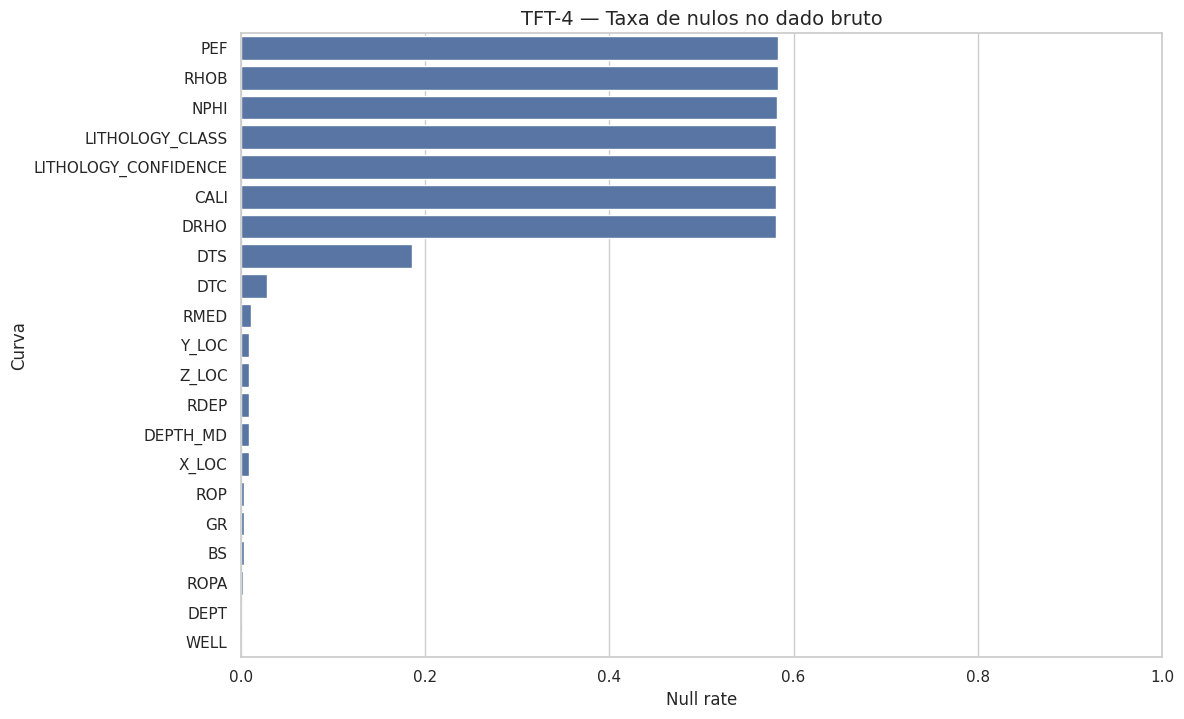

In [13]:
# ============================================================
# STEP 6.1 — MATRIZ DE NULOS DO DADO BRUTO
# ============================================================

raw_null_rate = (
    raw_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("NULL_RATE")
    .to_frame()
)

raw_null_rate["FILL_RATE"] = 1 - raw_null_rate["NULL_RATE"]
display(raw_null_rate)

plt.figure(figsize=(12, max(5, len(raw_null_rate) * 0.35)))
sns.barplot(
    data=raw_null_rate.reset_index().rename(columns={"index": "CURVE"}),
    y="CURVE",
    x="NULL_RATE",
    orient="h"
)
plt.title(f"{WELL_NAME} — Taxa de nulos no dado bruto")
plt.xlabel("Null rate")
plt.ylabel("Curva")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

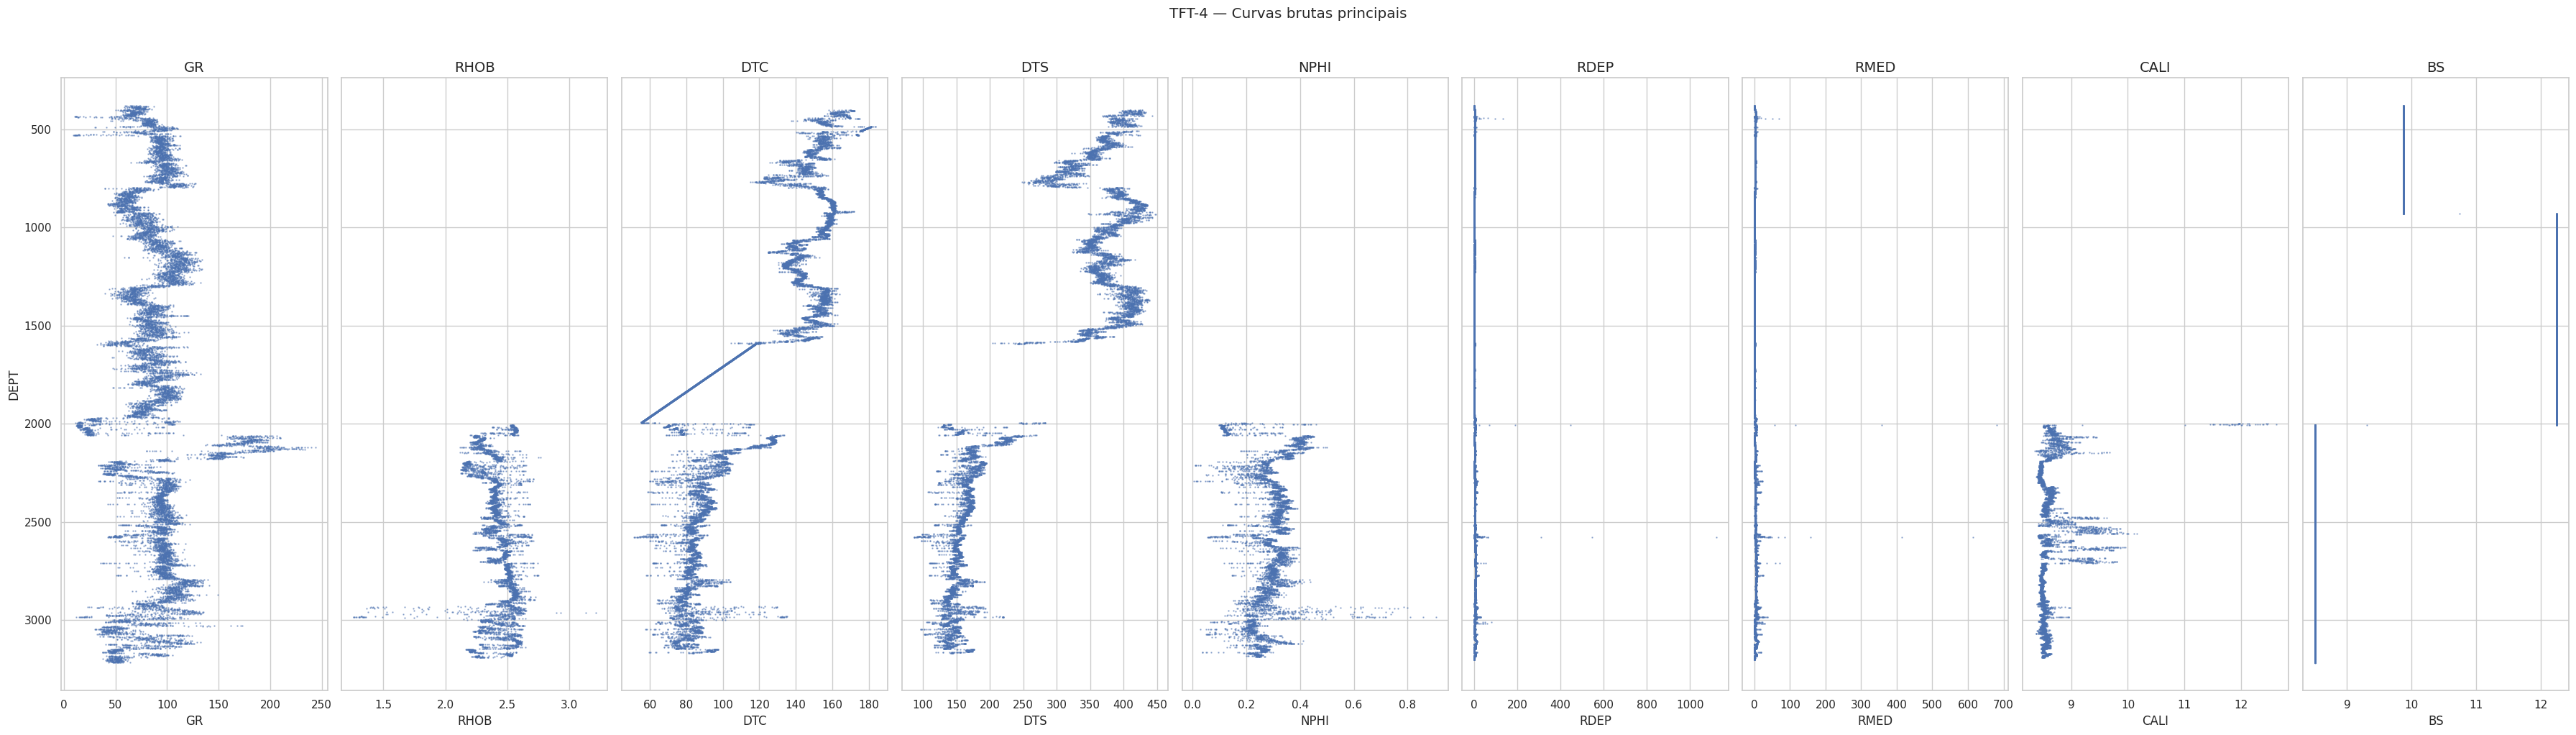

In [14]:
# ============================================================
# STEP 6.2 — QUICK LOG PLOT DAS CURVAS PRINCIPAIS
# ============================================================

def plot_log_curves(
    df: pd.DataFrame,
    depth_col: str,
    curves: List[str],
    title: str,
    max_points: int = 30_000,
) -> None:
    """
    Plota curvas contra profundidade.

    Para evitar gráficos pesados demais, se houver muitos pontos,
    usamos amostragem regular com iloc.

    Atenção:
    --------
    Este gráfico não decide se o dado é bom ou ruim.
    Ele serve para inspeção visual inicial.
    """
    existing_curves = [c for c in curves if c in df.columns]

    if not existing_curves:
        print("Nenhuma curva solicitada existe no DataFrame.")
        return

    plot_df = df[[depth_col] + existing_curves].copy()
    plot_df = plot_df.dropna(subset=[depth_col])

    if len(plot_df) > max_points:
        step = max(1, len(plot_df) // max_points)
        plot_df = plot_df.iloc[::step].copy()

    n = len(existing_curves)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 10), sharey=True)

    if n == 1:
        axes = [axes]

    for ax, curve in zip(axes, existing_curves):
        ax.plot(plot_df[curve], plot_df[depth_col], ".", markersize=1.5, alpha=0.5)
        ax.set_title(curve)
        ax.set_xlabel(curve)
        ax.grid(True)

    axes[0].invert_yaxis()
    axes[0].set_ylabel(depth_col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


main_curves = ["GR", "RHOB", "DTC", "DTS", "NPHI", "RDEP", "RMED", "CALI", "BS"]
plot_log_curves(raw_df, depth_col_raw, main_curves, f"{WELL_NAME} — Curvas brutas principais")

# STEP 7 — Standardization

Agora padronizamos nomes de colunas, tipos e estrutura.

Objetivo:
- criar coluna única de profundidade chamada `DEPTH`;
- manter `WELL`;
- padronizar nomes equivalentes;
- remover ambiguidades como `DEPT` versus `DEPTH_MD`;
- converter colunas numéricas para número;
- ordenar por profundidade.

Essa etapa cria uma base mais confiável para todo o resto.

In [15]:
# ============================================================
# STEP 7 — STANDARDIZATION
# ============================================================

COLUMN_MAPPING = {
    # Profundidade
    "DEPT": "DEPTH",
    "DEPTH_MD": "DEPTH",
    "MD": "DEPTH",

    # Neutron porosity
    "NPHI": "NPOR",
    "PHIN": "NPOR",

    # Resistividade profunda
    "ILD": "RDEP",
    "RT": "RDEP",

    # Resistividade média
    "ILM": "RMED",

    # Resistividade rasa
    "LLS": "RSHA",
}


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Padroniza nomes e organiza o DataFrame.

    Importante:
    -----------
    Se duas colunas virarem o mesmo nome após rename,
    por exemplo DEPT e DEPTH_MD -> DEPTH,
    precisamos consolidar.

    Estratégia:
    -----------
    - cria nomes padronizados;
    - se houver colunas duplicadas, combina usando bfill horizontal;
    - mantém a primeira informação válida entre duplicatas.
    """
    out = df.copy()

    out.columns = (
        pd.Index(out.columns)
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "_", regex=False)
    )

    out = out.rename(columns=COLUMN_MAPPING)

    # Consolida colunas duplicadas geradas pelo rename.
    duplicated_names = out.columns[out.columns.duplicated()].unique().tolist()

    for col in duplicated_names:
        same_cols = out.loc[:, out.columns == col]

        # bfill(axis=1) pega o primeiro valor não nulo da esquerda para direita.
        consolidated = same_cols.bfill(axis=1).iloc[:, 0]

        out = out.loc[:, out.columns != col]
        out[col] = consolidated

    # Garante WELL.
    if "WELL" not in out.columns:
        out["WELL"] = WELL_NAME

    # Converte todas as colunas exceto WELL para numérico quando possível.
    for col in out.columns:
        if col != "WELL":
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "DEPTH" not in out.columns:
        raise ValueError("Após padronização, coluna DEPTH não foi encontrada.")

    # Ordena por profundidade.
    out = out.sort_values("DEPTH").reset_index(drop=True)

    return out


std_df = standardize_columns(raw_df)

print(f"Shape após padronização: {std_df.shape}")
print("Colunas padronizadas:")
print(std_df.columns.tolist())

display(std_df.head())
display(std_df.tail())

Shape após padronização: (18731, 20)
Colunas padronizadas:
['LITHOLOGY_CONFIDENCE', 'LITHOLOGY_CLASS', 'CALI', 'BS', 'ROPA', 'ROP', 'RDEP', 'RMED', 'DTS', 'DTC', 'NPOR', 'PEF', 'GR', 'RHOB', 'DRHO', 'X_LOC', 'Y_LOC', 'Z_LOC', 'WELL', 'DEPTH']


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.008400
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.160400
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.312400
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.464400
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,372.616400


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH
18726,NaN,NaN,NaN,NaN,32.203064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,"3,218.360400"
18727,NaN,NaN,NaN,NaN,28.998888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,"3,218.512400"
18728,NaN,NaN,NaN,NaN,25.799675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,"3,218.664400"
18729,NaN,NaN,NaN,NaN,22.596163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,"3,218.816400"
18730,NaN,NaN,NaN,NaN,19.393373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TFT-4,"3,218.968400"


# STEP 8 — Invalid Values

Arquivos LAS frequentemente trazem valores inválidos codificados como números.

Exemplos comuns:
- -999.25
- -999.0
- -9999
- -99999
- às vezes 0 em curvas onde zero não faz sentido físico, como RHOB, DTC, DTS.

Nesta etapa, tratamos primeiro os placeholders clássicos.

Zeros físicos serão tratados com mais cuidado nos blocos de QC físico, porque em algumas curvas zero pode até ser válido, mas em outras quase nunca é.

In [16]:
# ============================================================
# STEP 8 — INVALID VALUES
# ============================================================

INVALID_PLACEHOLDERS = [
    -999.25,
    -999.0,
    -999.9,
    -999.90,
    -999.900024,
    -9999.0,
    -99999.0,
    -999.250122,
]

def replace_invalid_placeholders(df: pd.DataFrame, invalid_values: List[float]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Substitui placeholders inválidos por NaN.

    Usa pandas de forma vetorizada:
    - isin para detectar valores inválidos em todas as colunas numéricas;
    - sum para contar ocorrências por coluna;
    - replace para substituição global.
    """
    out = df.copy()

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()

    invalid_counts = (
        out[numeric_cols]
        .isin(invalid_values)
        .sum()
        .sort_values(ascending=False)
        .rename("INVALID_PLACEHOLDER_COUNT")
        .to_frame()
    )

    invalid_counts = invalid_counts[invalid_counts["INVALID_PLACEHOLDER_COUNT"] > 0]

    out[numeric_cols] = out[numeric_cols].replace(invalid_values, np.nan)

    return out, invalid_counts


clean_step8_df, invalid_counts_df = replace_invalid_placeholders(std_df, INVALID_PLACEHOLDERS)

print("Valores inválidos detectados por coluna:")
display(invalid_counts_df)

invalid_counts_path = REPORT_DIR / f"{WELL_NAME}_invalid_placeholder_counts.csv"
invalid_counts_df.to_csv(invalid_counts_path)
print(f"Relatório de placeholders inválidos salvo em: {invalid_counts_path}")

Valores inválidos detectados por coluna:


,INVALID_PLACEHOLDER_COUNT


Relatório de placeholders inválidos salvo em: ../reports/single_well_qc/TFT-4_invalid_placeholder_counts.csv


# STEP 9 — Null Analysis

Agora analisamos os nulos depois de tratar placeholders.

Não vamos remover nulos cegamente.

Em logs de poço, nulos podem indicar:
- curva não adquirida;
- trecho sem leitura;
- ferramenta fora do poço;
- zona sem amostragem;
- problema de merge;
- intervalo de má qualidade;
- ausência legítima de curva.

A análise de nulos deve responder:
- quais curvas são mais completas?
- quais curvas são quase vazias?
- quais intervalos de profundidade concentram nulos?
- ainda temos DTC/DTS/RHOB suficientes?

In [17]:
# ============================================================
# STEP 9 — NULL ANALYSIS
# ============================================================

def null_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria relatório de nulos por coluna.

    Usa pandas vetorizado:
    - isna().sum()
    - isna().mean()
    - notna().sum()
    - notna().mean()
    """
    report = pd.DataFrame({
        "NON_NULL_COUNT": df.notna().sum(),
        "NULL_COUNT": df.isna().sum(),
        "FILL_RATE": df.notna().mean(),
        "NULL_RATE": df.isna().mean(),
        "TOTAL_ROWS": len(df),
    })

    return report.sort_values("NULL_RATE", ascending=False)


null_report_df = null_report(clean_step8_df)

display(null_report_df)

null_report_path = REPORT_DIR / f"{WELL_NAME}_null_report_after_invalid_values.csv"
null_report_df.to_csv(null_report_path)
print(f"Relatório de nulos salvo em: {null_report_path}")

,NON_NULL_COUNT,NULL_COUNT,FILL_RATE,NULL_RATE,TOTAL_ROWS
RHOB,7800,10931,0.416422,0.583578,18731
PEF,7800,10931,0.416422,0.583578,18731
NPOR,7835,10896,0.418291,0.581709,18731
LITHOLOGY_CLASS,7840,10891,0.418557,0.581443,18731
LITHOLOGY_CONFIDENCE,7841,10890,0.418611,0.581389,18731
CALI,7842,10889,0.418664,0.581336,18731
DRHO,7846,10885,0.418878,0.581122,18731
DTS,15252,3479,0.814265,0.185735,18731
DTC,18199,532,0.971598,0.028402,18731
RMED,18524,207,0.988949,0.011051,18731


Relatório de nulos salvo em: ../reports/single_well_qc/TFT-4_null_report_after_invalid_values.csv


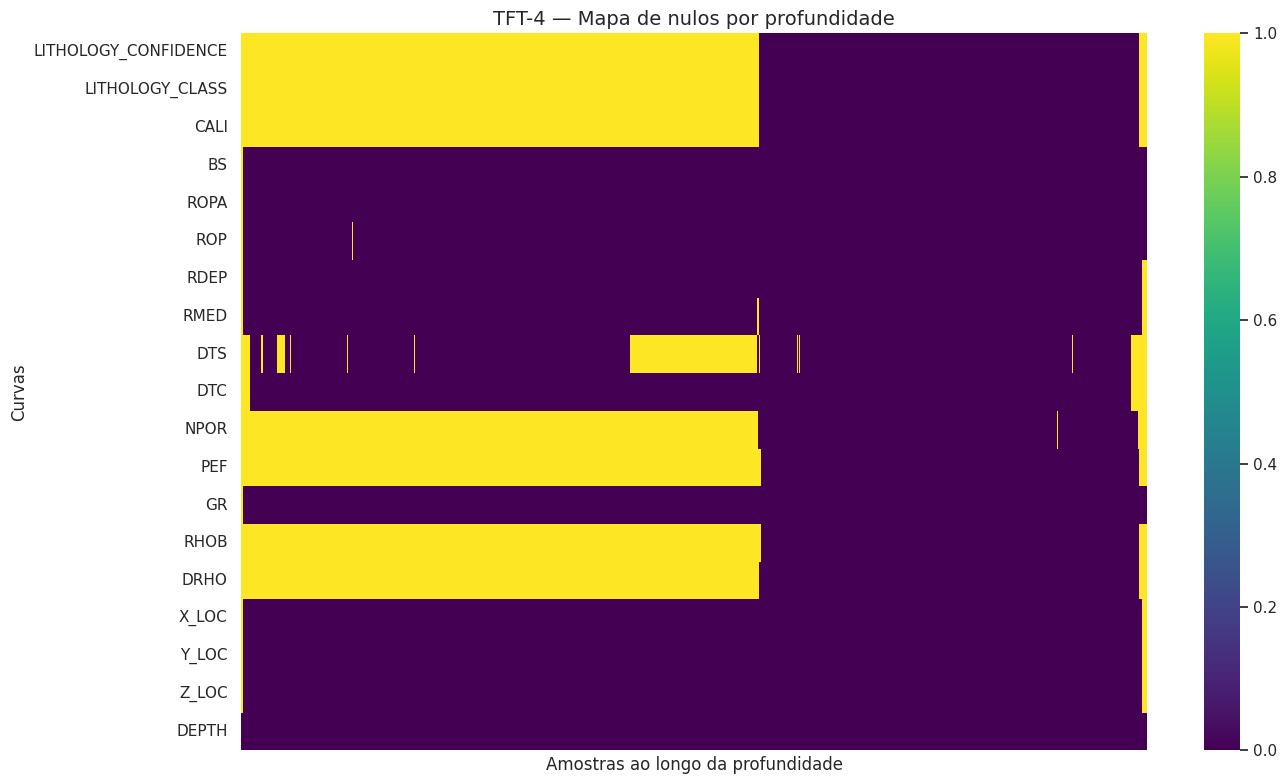

In [18]:
# ============================================================
# STEP 9.1 — MAPA VISUAL DE NULOS POR PROFUNDIDADE
# ============================================================

# Para visualizar nulos por profundidade, criamos uma matriz booleana:
# True  -> valor nulo
# False -> valor presente
#
# Como heatmap com muitas linhas pode pesar, fazemos downsample.

def plot_null_heatmap(df: pd.DataFrame, depth_col: str = "DEPTH", max_rows: int = 5_000) -> None:
    plot_cols = [c for c in df.columns if c != "WELL"]

    plot_df = df[plot_cols].copy()

    if len(plot_df) > max_rows:
        step = max(1, len(plot_df) // max_rows)
        plot_df = plot_df.iloc[::step].copy()

    null_matrix = plot_df.isna().astype(int)

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        null_matrix.T,
        cbar=True,
        cmap="viridis",
        xticklabels=False,
        yticklabels=True
    )
    plt.title(f"{WELL_NAME} — Mapa de nulos por profundidade")
    plt.xlabel("Amostras ao longo da profundidade")
    plt.ylabel("Curvas")
    plt.tight_layout()
    plt.show()


plot_null_heatmap(clean_step8_df, "DEPTH")

# STEP 10 — Duplicates

Agora verificamos duplicatas.

Existem dois tipos importantes:

1. **Duplicata completa da linha**  
   A linha inteira é repetida.

2. **Duplicata de profundidade**  
   A profundidade aparece mais de uma vez, mesmo que outras curvas mudem.

Para modelagem e resampling, profundidade duplicada é especialmente perigosa.

In [19]:
# ============================================================
# STEP 10 — DUPLICATES
# ============================================================

def duplicate_report(df: pd.DataFrame, depth_col: str = "DEPTH") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cria relatórios de duplicatas completas e duplicatas de profundidade.
    """
    complete_dup_mask = df.duplicated(keep=False)
    depth_dup_mask = df[depth_col].duplicated(keep=False)

    complete_dups = df.loc[complete_dup_mask].copy()
    depth_dups = df.loc[depth_dup_mask].copy().sort_values(depth_col)

    summary = pd.DataFrame([{
        "TOTAL_ROWS": len(df),
        "COMPLETE_DUPLICATED_ROWS": complete_dup_mask.sum(),
        "DUPLICATED_DEPTH_ROWS": depth_dup_mask.sum(),
        "UNIQUE_DEPTHS": df[depth_col].nunique(dropna=True),
    }])

    return summary, complete_dups, depth_dups


dup_summary_df, complete_dups_df, depth_dups_df = duplicate_report(clean_step8_df, "DEPTH")

display(dup_summary_df)

print("Duplicatas completas — amostra:")
display(complete_dups_df.head(20))

print("Profundidades duplicadas — amostra:")
display(depth_dups_df.head(50))

dup_summary_path = REPORT_DIR / f"{WELL_NAME}_duplicate_summary.csv"
depth_dups_path = REPORT_DIR / f"{WELL_NAME}_duplicated_depths.csv"

dup_summary_df.to_csv(dup_summary_path, index=False)
depth_dups_df.to_csv(depth_dups_path, index=False)

print(f"Resumo de duplicatas salvo em: {dup_summary_path}")
print(f"Profundidades duplicadas salvas em: {depth_dups_path}")

,TOTAL_ROWS,COMPLETE_DUPLICATED_ROWS,DUPLICATED_DEPTH_ROWS,UNIQUE_DEPTHS
0,18731,0,0,18731


Duplicatas completas — amostra:


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH


Profundidades duplicadas — amostra:


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,WELL,DEPTH


Resumo de duplicatas salvo em: ../reports/single_well_qc/TFT-4_duplicate_summary.csv
Profundidades duplicadas salvas em: ../reports/single_well_qc/TFT-4_duplicated_depths.csv


In [20]:
# ============================================================
# STEP 10.1 — REMOÇÃO CONTROLADA DE DUPLICATAS
# ============================================================

def remove_duplicates_controlled(df: pd.DataFrame, depth_col: str = "DEPTH") -> pd.DataFrame:
    """
    Remove duplicatas de forma controlada.

    Estratégia:
    -----------
    1. Remove duplicatas completas.
    2. Para profundidade duplicada, consolida usando média das colunas numéricas.
       Isso evita descartar informação quando duas linhas têm a mesma profundidade,
       mas valores parcialmente diferentes.

    Observação:
    -----------
    Em um projeto petrofísico profissional, dependendo do caso,
    você poderia investigar manualmente as duplicatas antes de consolidar.
    Aqui fazemos uma consolidação auditável e simples.
    """
    out = df.copy()

    # Remove duplicatas completas.
    out = out.drop_duplicates().copy()

    numeric_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    non_numeric_cols = [c for c in out.columns if c not in numeric_cols]

    # Para numéricos: média por profundidade.
    numeric_grouped = out.groupby(depth_col, as_index=False)[numeric_cols].mean()

    # Para não numéricos: primeiro valor por profundidade.
    if non_numeric_cols:
        non_numeric_grouped = out.groupby(depth_col, as_index=False)[non_numeric_cols].first()
        result = numeric_grouped.merge(non_numeric_grouped, on=depth_col, how="left")
    else:
        result = numeric_grouped

    result = result.sort_values(depth_col).reset_index(drop=True)

    return result


clean_step10_df = remove_duplicates_controlled(clean_step8_df, "DEPTH")

print(f"Shape antes:  {clean_step8_df.shape}")
print(f"Shape depois: {clean_step10_df.shape}")
print(f"Profundidades duplicadas restantes: {clean_step10_df['DEPTH'].duplicated().sum()}")

display(clean_step10_df.head())

Shape antes:  (18731, 20)
Shape depois: (18731, 20)
Profundidades duplicadas restantes: 0


,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,DEPTH,WELL
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.008400,TFT-4
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.160400,TFT-4
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.312400,TFT-4
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.464400,TFT-4
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,372.616400,TFT-4


# STEP 11 — Physical Range QC

Agora começa o QC físico.

Aqui definimos faixas esperadas ou suspeitas para curvas principais.

Importante:

> O objetivo desta etapa não é remover tudo automaticamente.  
> O objetivo é criar flags de suspeita.

Faixas típicas usadas como referência inicial:

- GR: 0 a 300 API como faixa ampla inicial;
- RHOB: 1.5 a 3.0 g/cm³ como faixa útil principal;
- DTC: 40 a 200 us/ft como faixa conservadora;
- DTS: 80 a 400 us/ft como faixa inicial ampla;
- NPOR: -0.15 a 0.60 fração;
- RDEP/RMED/RSHA: valores positivos, analisados melhor em escala log;
- CALI/BS: devem ser positivos e coerentes entre si.

Esses limites devem ser ajustados conforme bacia, litologia, ferramenta e objetivo.

In [21]:
# ============================================================
# STEP 11 — PHYSICAL RANGE QC
# ============================================================

PHYSICAL_RULES = {
    # curve: min_allowed, max_allowed, zero_is_invalid
    "GR":   {"min": 0.0,   "max": 300.0, "zero_invalid": False, "description": "Gamma Ray"},
    "RHOB": {"min": 1.5,   "max": 3.0,   "zero_invalid": True,  "description": "Bulk Density"},
    "DTC":  {"min": 40.0,  "max": 200.0, "zero_invalid": True,  "description": "Compressional Sonic"},
    "DTS":  {"min": 80.0,  "max": 400.0, "zero_invalid": True,  "description": "Shear Sonic"},
    "NPOR": {"min": -0.15, "max": 0.60,  "zero_invalid": False, "description": "Neutron Porosity"},
    "RDEP": {"min": 0.001, "max": 2000.0,"zero_invalid": True,  "description": "Deep Resistivity"},
    "RMED": {"min": 0.001, "max": 2000.0,"zero_invalid": True,  "description": "Medium Resistivity"},
    "RSHA": {"min": 0.001, "max": 2000.0,"zero_invalid": True,  "description": "Shallow Resistivity"},
    "CALI": {"min": 2.0,   "max": 40.0,  "zero_invalid": True,  "description": "Caliper"},
    "BS":   {"min": 2.0,   "max": 40.0,  "zero_invalid": True,  "description": "Bit Size"},
}


def apply_physical_qc_flags(df: pd.DataFrame, rules: Dict[str, Dict[str, object]]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Aplica flags de QC físico.

    Para cada curva, cria:
    - FLAG_<CURVE>_LOW
    - FLAG_<CURVE>_HIGH
    - FLAG_<CURVE>_ZERO
    - FLAG_<CURVE>_SUSPICIOUS

    Usa operações vetorizadas do pandas/numpy.
    """
    out = df.copy()
    summary_rows = []

    for curve, rule in rules.items():
        if curve not in out.columns:
            continue

        min_v = float(rule["min"])
        max_v = float(rule["max"])
        zero_invalid = bool(rule["zero_invalid"])

        s = out[curve]

        low_flag = s.notna() & (s < min_v)
        high_flag = s.notna() & (s > max_v)
        zero_flag = s.notna() & (s == 0) if zero_invalid else pd.Series(False, index=out.index)

        suspicious = low_flag | high_flag | zero_flag

        out[f"FLAG_{curve}_LOW"] = low_flag
        out[f"FLAG_{curve}_HIGH"] = high_flag
        out[f"FLAG_{curve}_ZERO"] = zero_flag
        out[f"FLAG_{curve}_SUSPICIOUS"] = suspicious

        valid_count = s.notna().sum()
        suspicious_count = suspicious.sum()

        summary_rows.append({
            "CURVE": curve,
            "DESCRIPTION": rule["description"],
            "MIN_RULE": min_v,
            "MAX_RULE": max_v,
            "ZERO_INVALID": zero_invalid,
            "VALID_COUNT": valid_count,
            "LOW_COUNT": low_flag.sum(),
            "HIGH_COUNT": high_flag.sum(),
            "ZERO_COUNT": zero_flag.sum(),
            "SUSPICIOUS_COUNT": suspicious_count,
            "SUSPICIOUS_RATE_OVER_VALID": suspicious_count / valid_count if valid_count else np.nan,
        })

    summary = pd.DataFrame(summary_rows).sort_values("SUSPICIOUS_RATE_OVER_VALID", ascending=False)

    return out, summary


qc_df, physical_qc_summary_df = apply_physical_qc_flags(clean_step10_df, PHYSICAL_RULES)

display(physical_qc_summary_df)

physical_qc_path = REPORT_DIR / f"{WELL_NAME}_physical_qc_summary.csv"
physical_qc_summary_df.to_csv(physical_qc_path, index=False)
print(f"Resumo de QC físico salvo em: {physical_qc_path}")

,CURVE,DESCRIPTION,MIN_RULE,MAX_RULE,ZERO_INVALID,VALID_COUNT,LOW_COUNT,HIGH_COUNT,ZERO_COUNT,SUSPICIOUS_COUNT,SUSPICIOUS_RATE_OVER_VALID
3,DTS,Shear Sonic,80.000000,400.000000,True,15252,0,2053,0,2053,0.134605
4,NPOR,Neutron Porosity,-0.150000,0.600000,False,7835,0,41,0,41,0.005233
1,RHOB,Bulk Density,1.500000,3.000000,True,7800,32,2,0,34,0.004359
0,GR,Gamma Ray,0.000000,300.000000,False,18666,0,0,0,0,0.000000
2,DTC,Compressional Sonic,40.000000,200.000000,True,18199,0,0,0,0,0.000000
5,RDEP,Deep Resistivity,0.001000,"2,000.000000",True,18567,0,0,0,0,0.000000
6,RMED,Medium Resistivity,0.001000,"2,000.000000",True,18524,0,0,0,0,0.000000
7,CALI,Caliper,2.000000,40.000000,True,7842,0,0,0,0,0.000000
8,BS,Bit Size,2.000000,40.000000,True,18674,0,0,0,0,0.000000


Resumo de QC físico salvo em: ../reports/single_well_qc/TFT-4_physical_qc_summary.csv


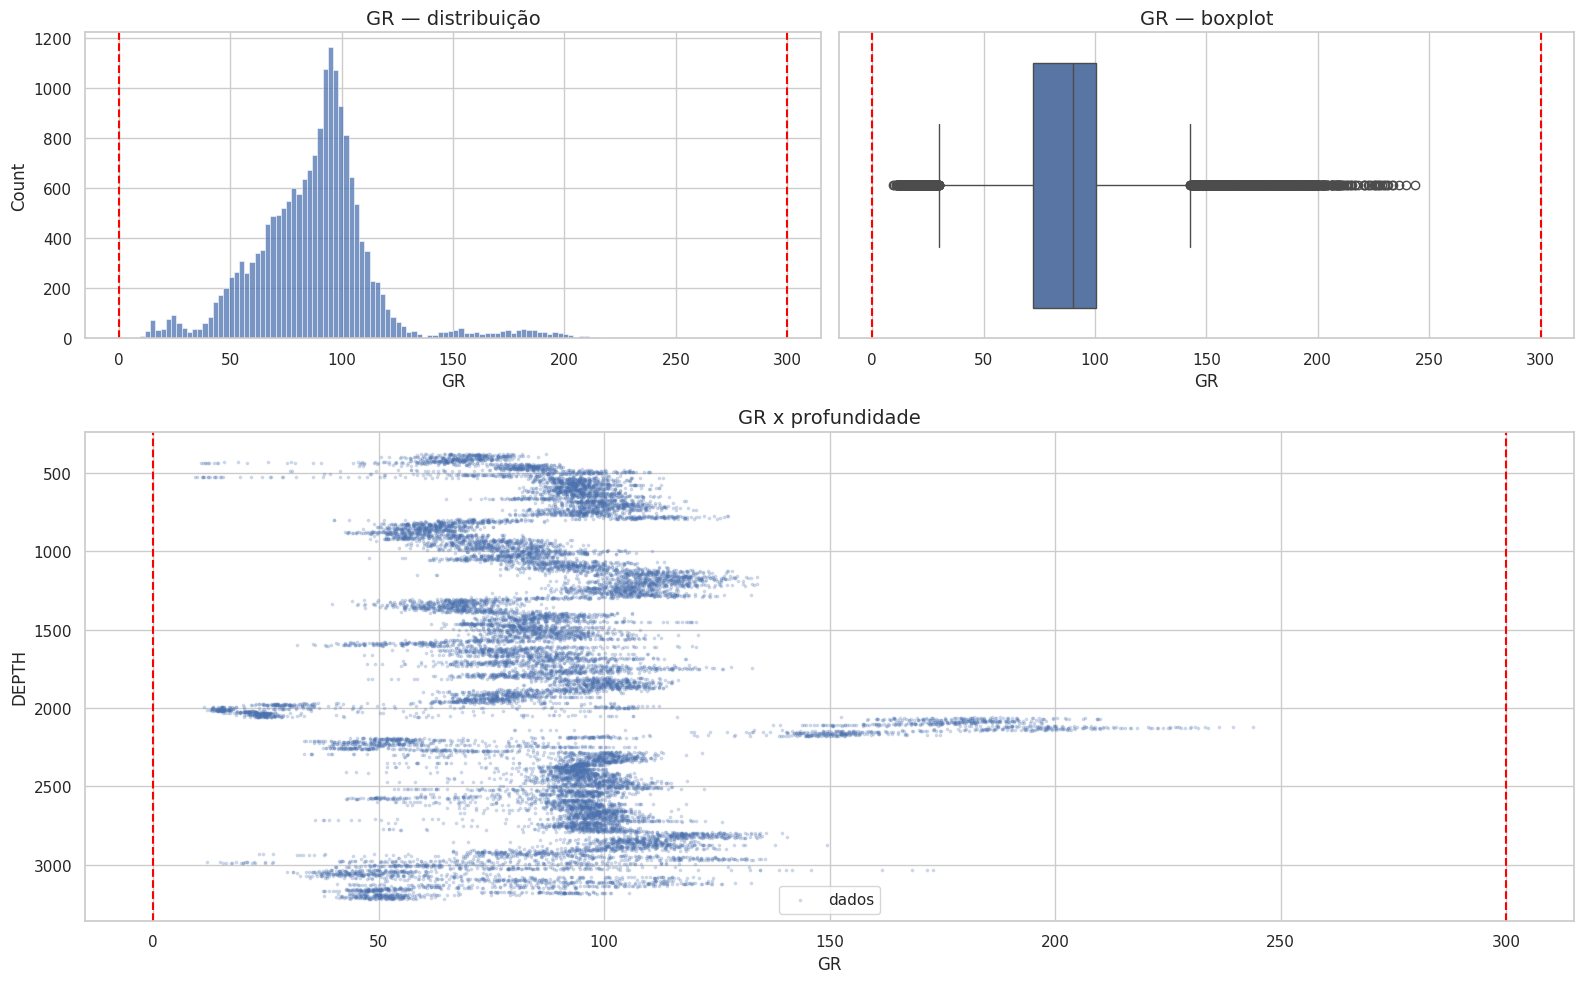

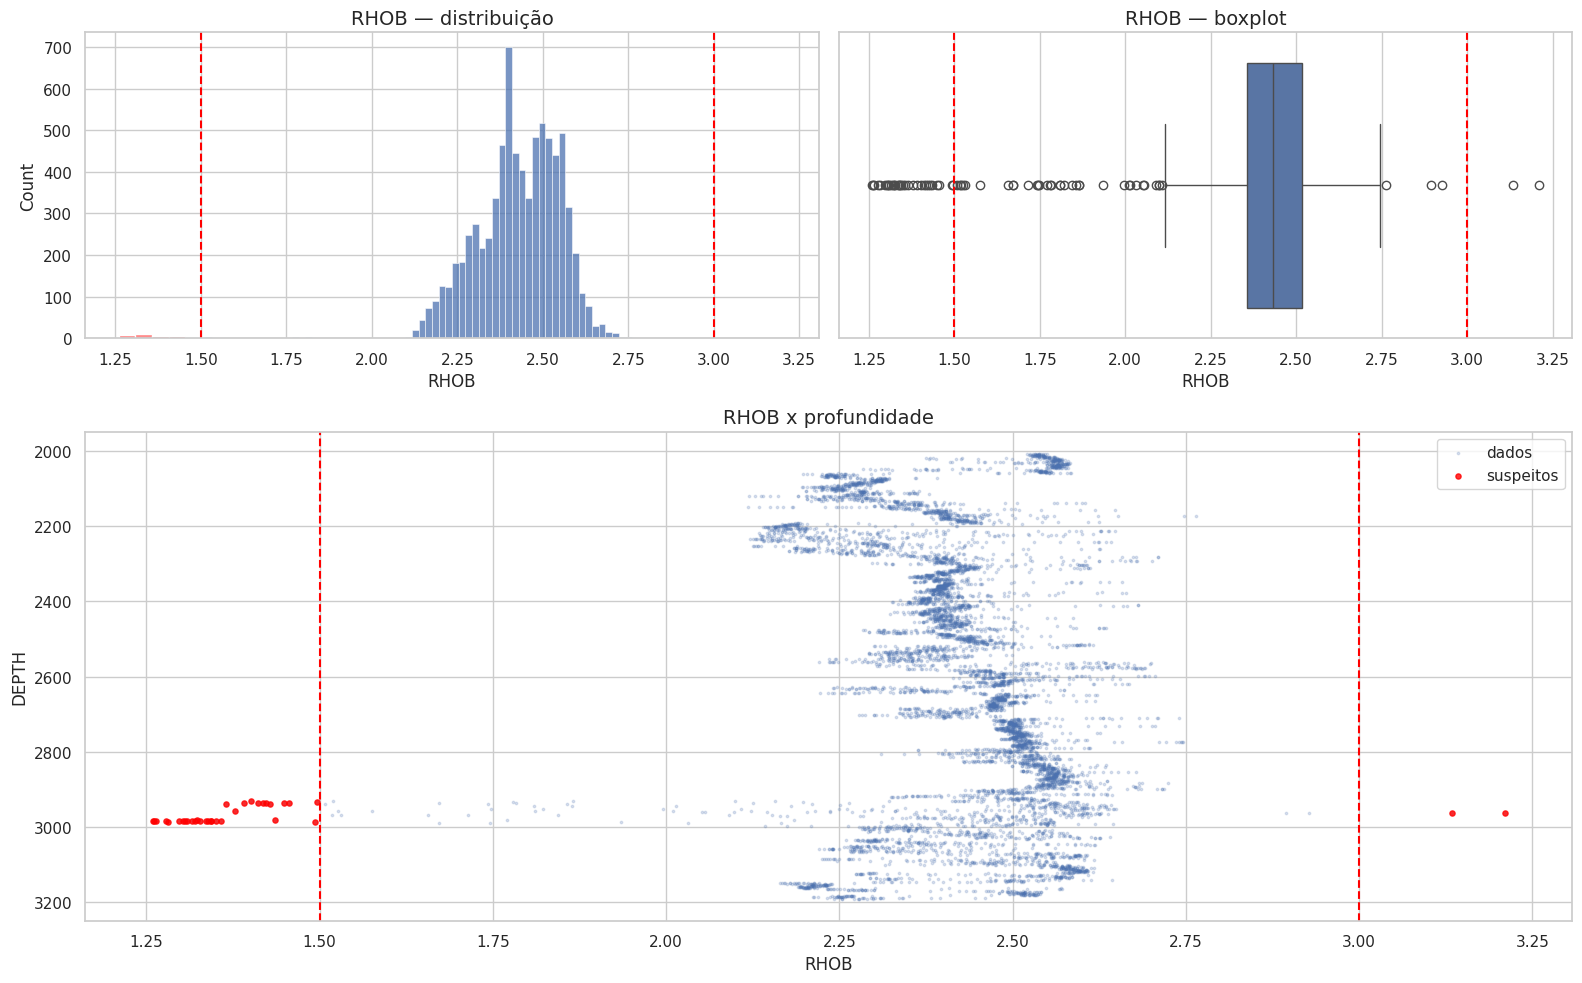

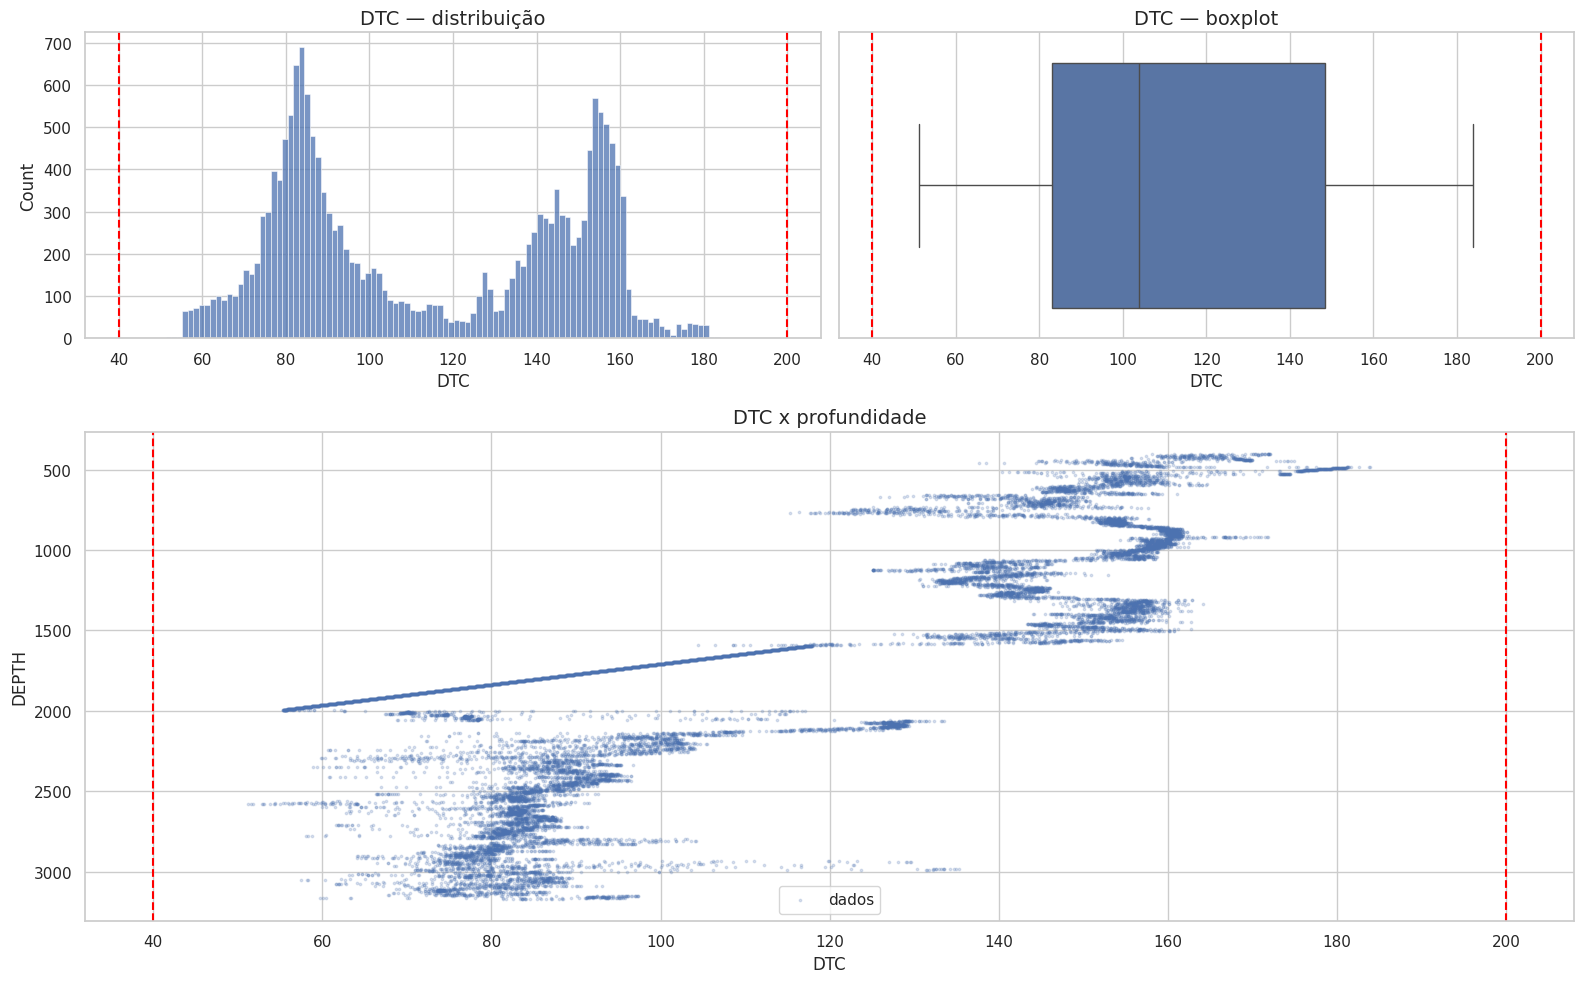

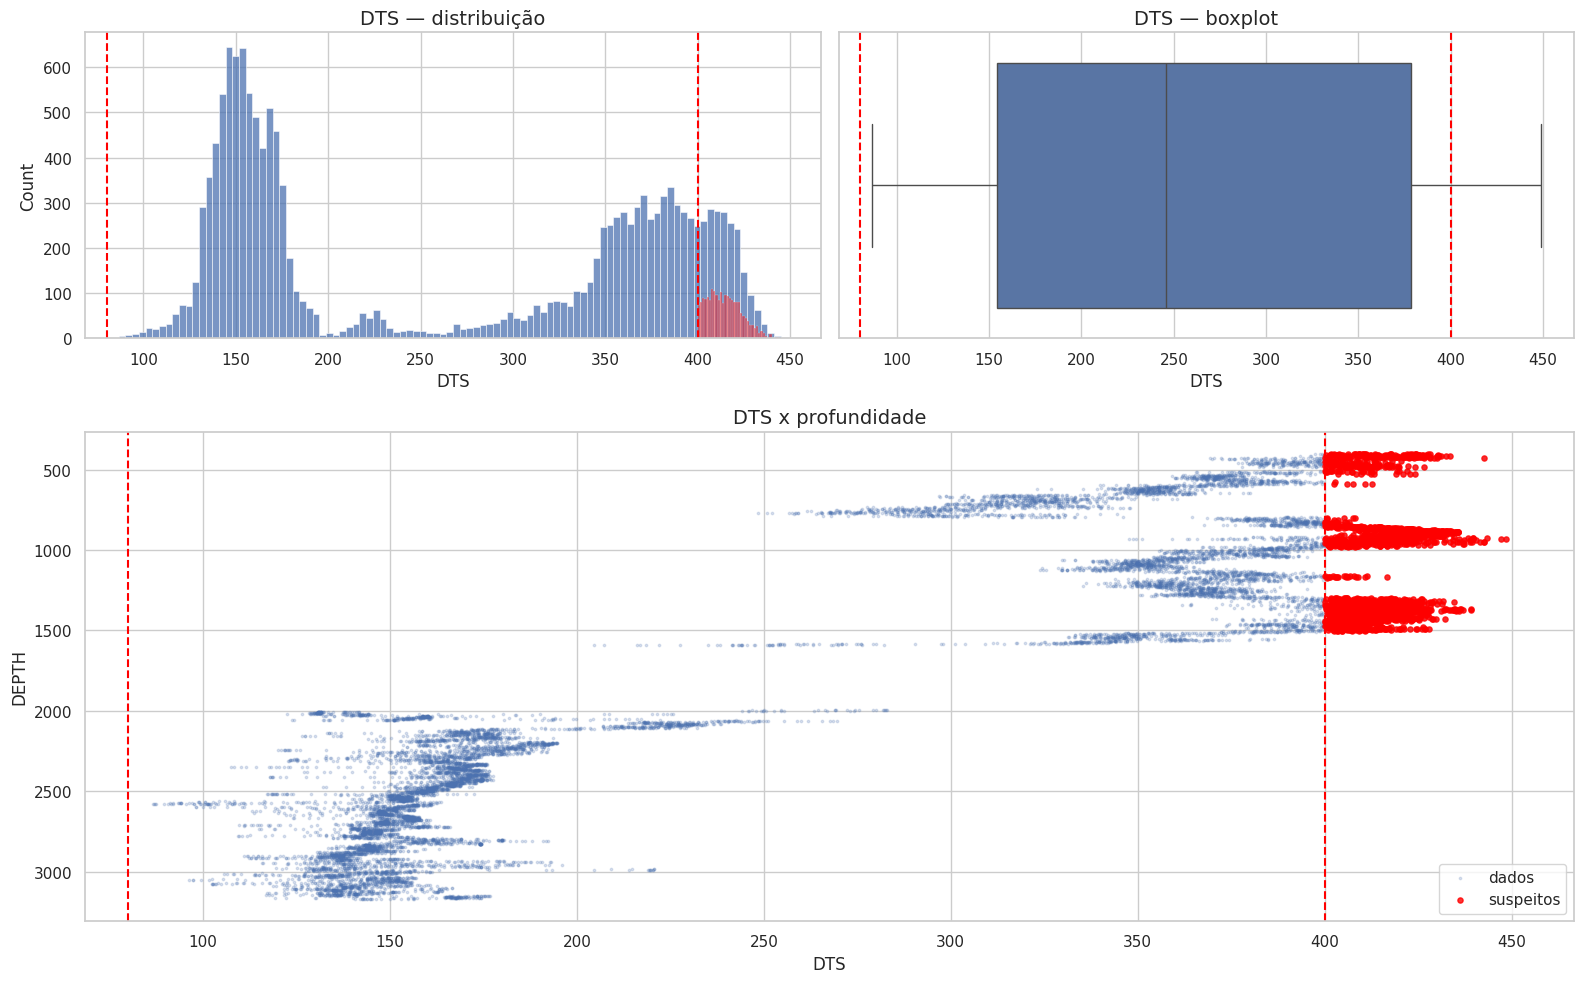

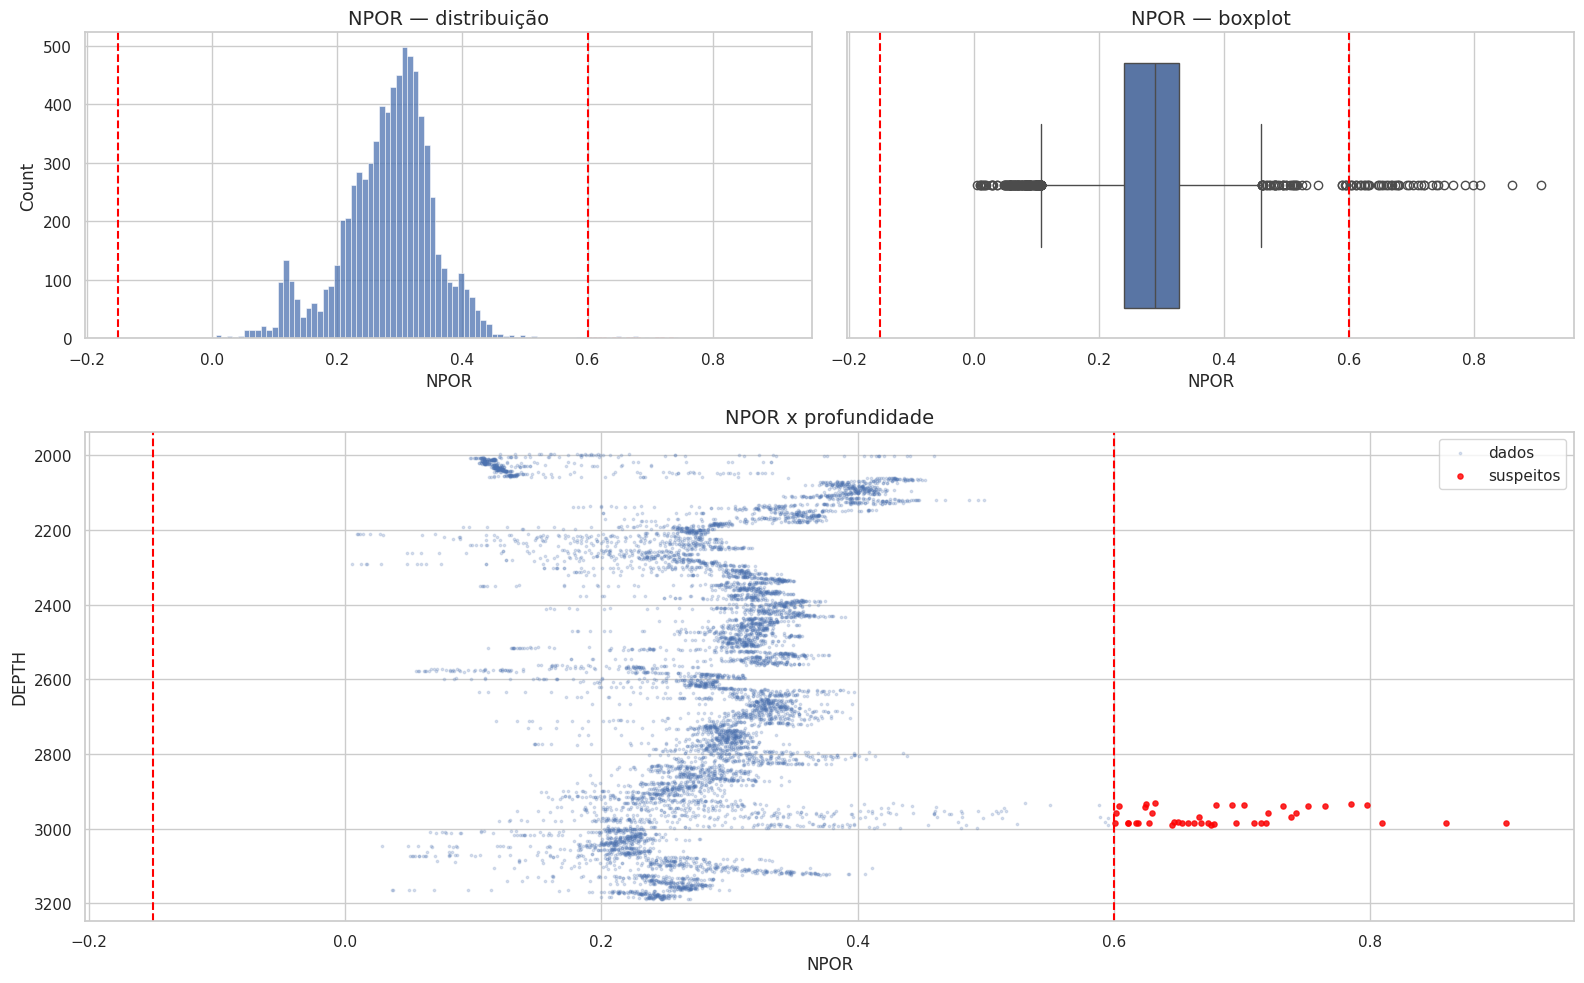

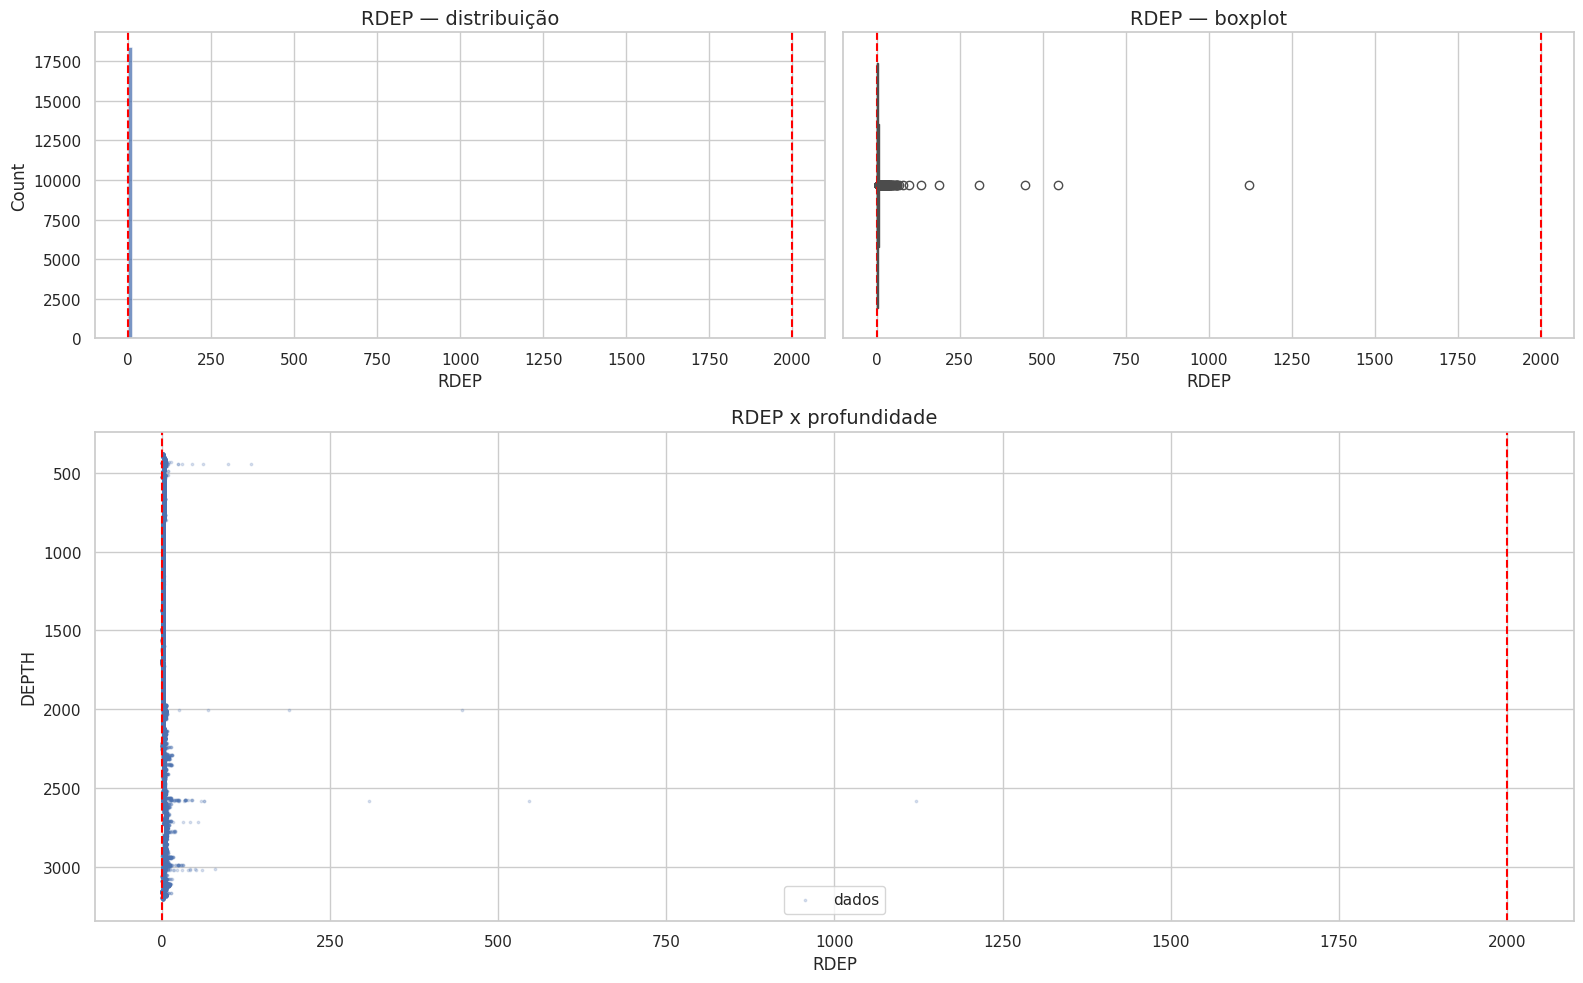

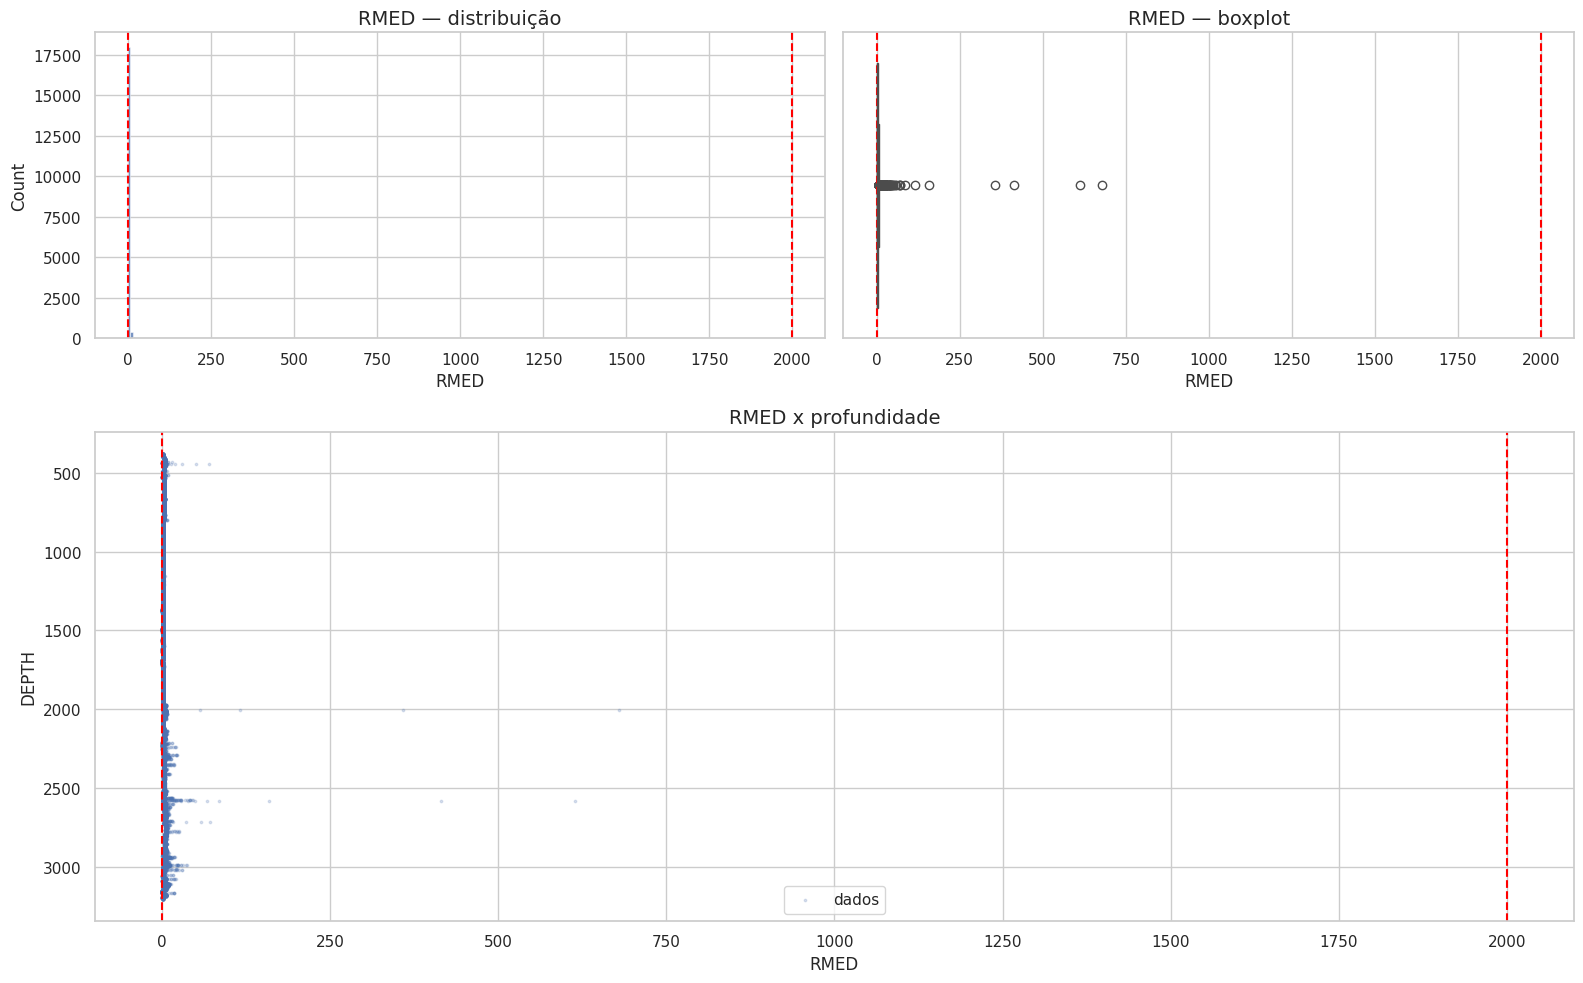

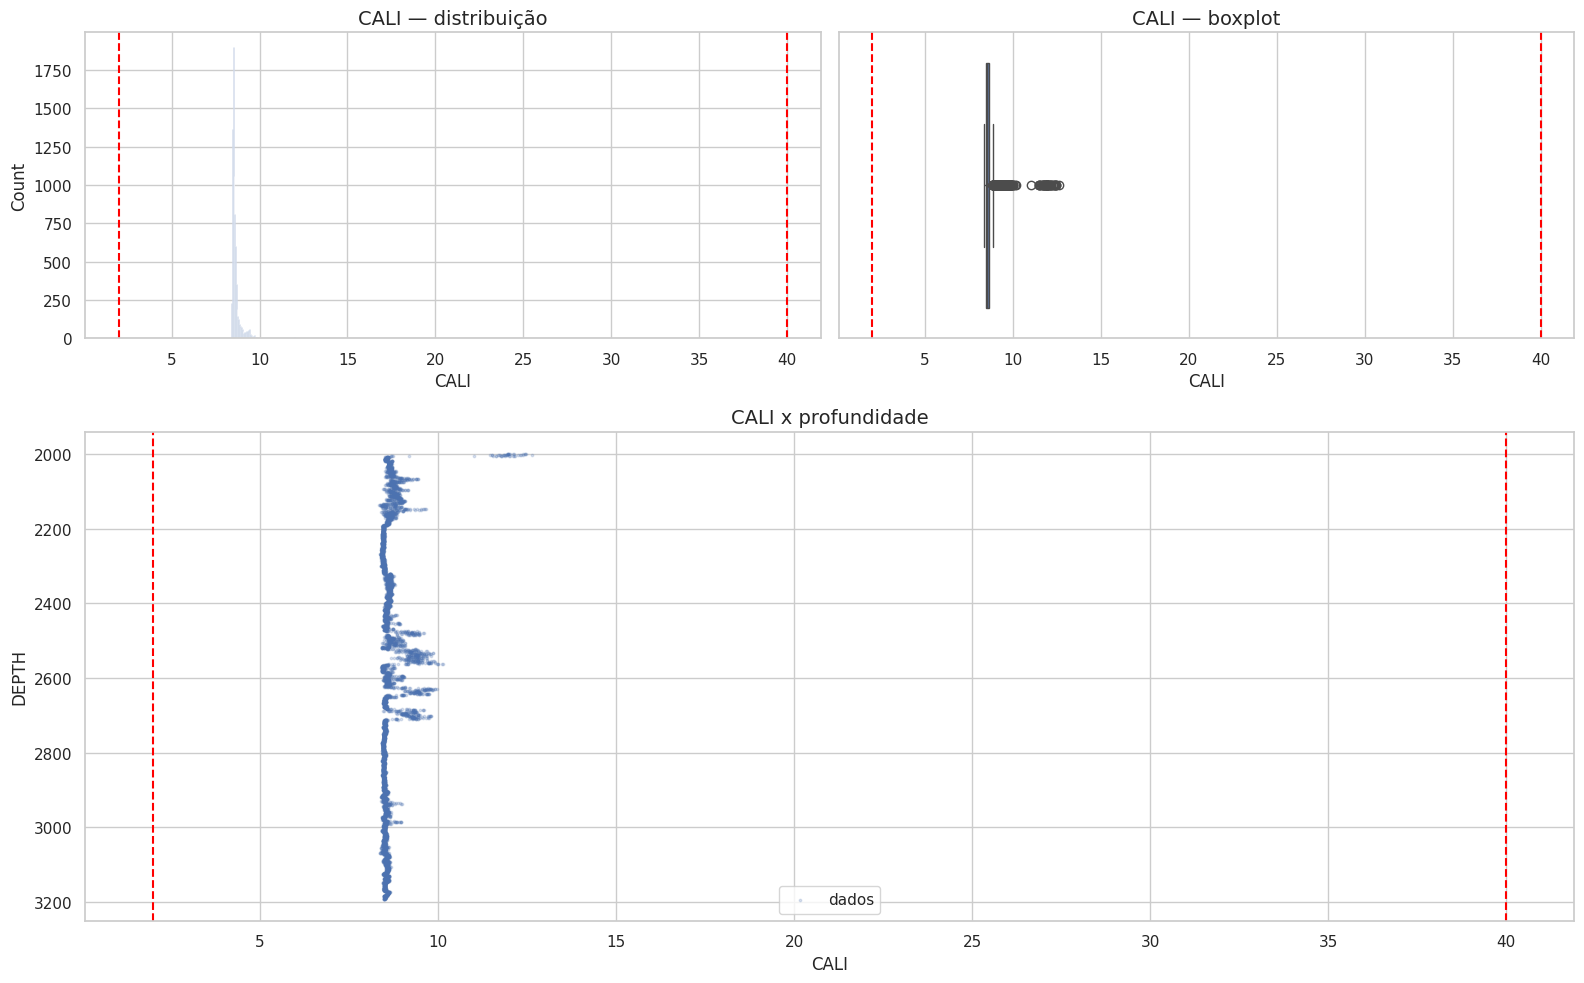

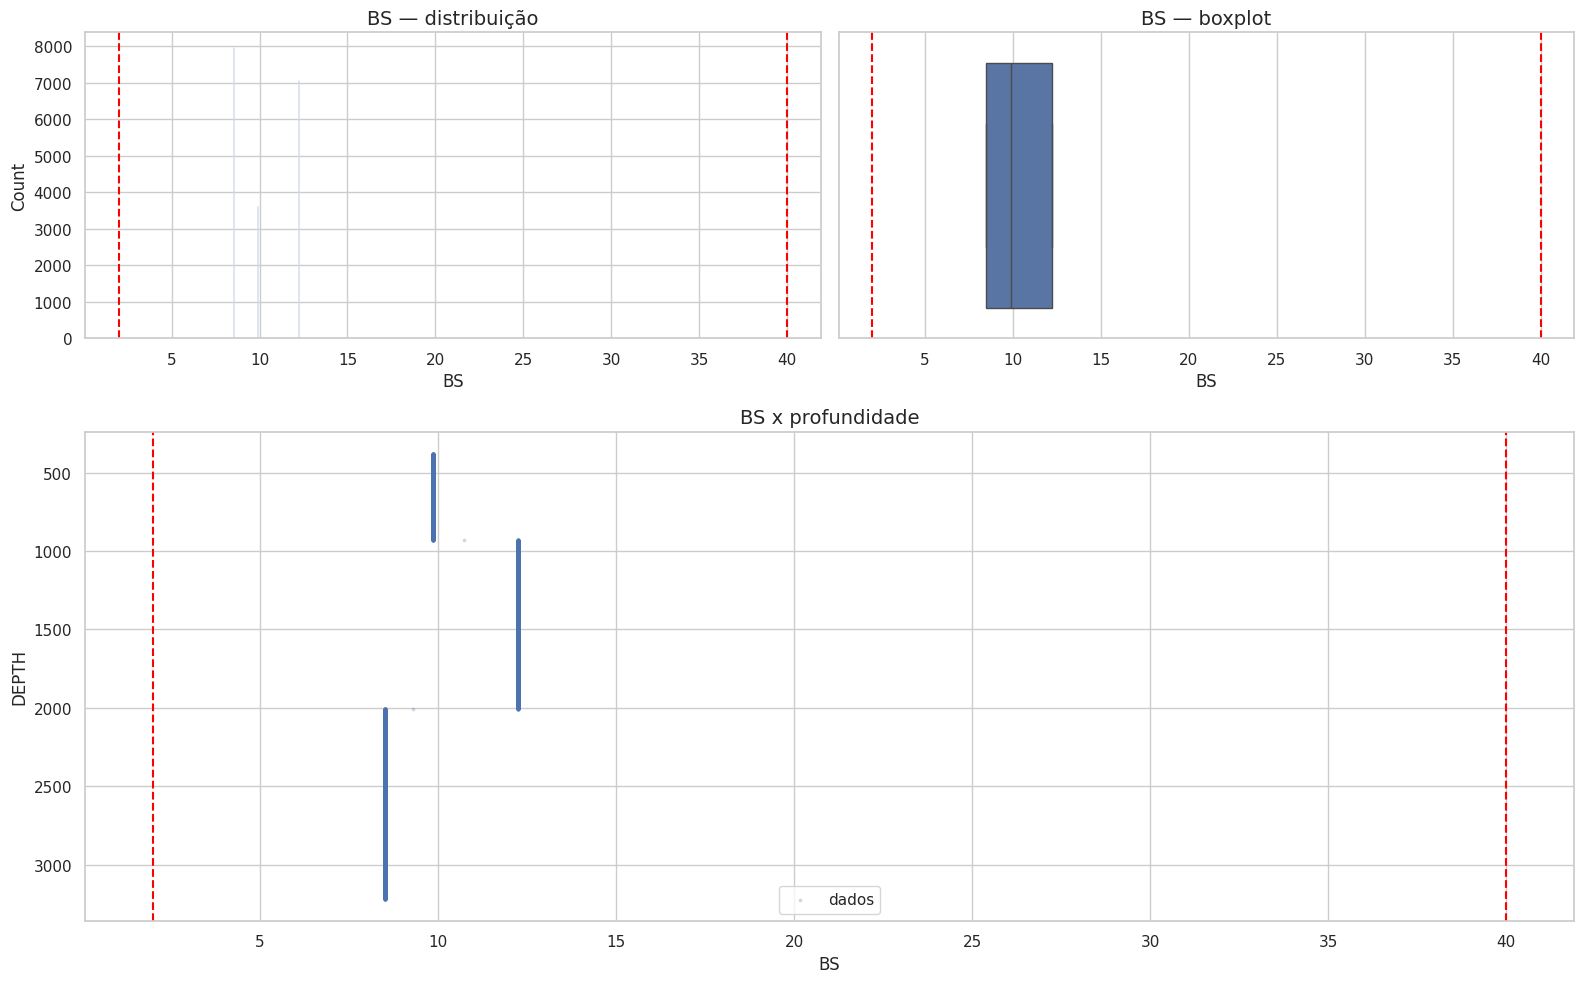

In [22]:
# ============================================================
# STEP 11.1 — GRÁFICOS DE QC FÍSICO POR CURVA
# ============================================================

def plot_curve_physical_qc(df: pd.DataFrame, curve: str, rules: Dict[str, Dict[str, object]], depth_col: str = "DEPTH") -> None:
    """
    Plota:
    1. histograma da curva;
    2. boxplot;
    3. curva versus profundidade com pontos suspeitos.

    Este gráfico é uma das ferramentas mais importantes para decidir:
    - erro bruto;
    - valor suspeito;
    - possível fenômeno real.
    """
    if curve not in df.columns or curve not in rules:
        print(f"Curva não disponível ou sem regra: {curve}")
        return

    rule = rules[curve]
    min_v = float(rule["min"])
    max_v = float(rule["max"])

    plot_df = df[[depth_col, curve]].dropna().copy()

    if plot_df.empty:
        print(f"Curva sem dados válidos: {curve}")
        return

    suspicious_col = f"FLAG_{curve}_SUSPICIOUS"

    if suspicious_col in df.columns:
        suspicious = df.loc[plot_df.index, suspicious_col]
    else:
        suspicious = (plot_df[curve] < min_v) | (plot_df[curve] > max_v)

    strange_df = plot_df.loc[suspicious].copy()

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.6])

    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(plot_df[curve], bins=100, ax=ax1)
    if not strange_df.empty:
        sns.histplot(strange_df[curve], bins=40, color="red", alpha=0.45, ax=ax1)
    ax1.axvline(min_v, color="red", linestyle="--")
    ax1.axvline(max_v, color="red", linestyle="--")
    ax1.set_title(f"{curve} — distribuição")
    ax1.set_xlabel(curve)

    ax2 = fig.add_subplot(gs[0, 1])
    sns.boxplot(x=plot_df[curve], ax=ax2)
    ax2.axvline(min_v, color="red", linestyle="--")
    ax2.axvline(max_v, color="red", linestyle="--")
    ax2.set_title(f"{curve} — boxplot")
    ax2.set_xlabel(curve)

    ax3 = fig.add_subplot(gs[1, :])
    ax3.scatter(plot_df[curve], plot_df[depth_col], s=3, alpha=0.20, label="dados")
    if not strange_df.empty:
        ax3.scatter(strange_df[curve], strange_df[depth_col], s=14, color="red", alpha=0.80, label="suspeitos")
    ax3.axvline(min_v, color="red", linestyle="--")
    ax3.axvline(max_v, color="red", linestyle="--")
    ax3.invert_yaxis()
    ax3.set_title(f"{curve} x profundidade")
    ax3.set_xlabel(curve)
    ax3.set_ylabel(depth_col)
    ax3.legend(loc="best")

    plt.tight_layout()
    plt.show()


for curve in ["GR", "RHOB", "DTC", "DTS", "NPOR", "RDEP", "RMED", "RSHA", "CALI", "BS"]:
    if curve in qc_df.columns:
        plot_curve_physical_qc(qc_df, curve, PHYSICAL_RULES, "DEPTH")

# STEP 12 — Outlier Investigation

Agora investigamos outliers sem removê-los cegamente.

Vamos combinar três abordagens:

1. **Outlier físico**  
   Baseado em limites de plausibilidade.

2. **Outlier estatístico por IQR**  
   Útil para detectar caudas, mas perigoso se usado sozinho.

3. **Outlier por robust z-score**  
   Usa mediana e MAD, mais robusto que média/desvio padrão.

Também vamos criar uma tabela com trechos suspeitos por profundidade.

In [23]:
# ============================================================
# STEP 12 — OUTLIER INVESTIGATION
# ============================================================

def add_iqr_outlier_flags(df: pd.DataFrame, curves: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Adiciona flags de outlier por IQR.

    Regra:
    - Q1 - 1.5*IQR
    - Q3 + 1.5*IQR

    Cuidado:
    --------
    Em petrofísica, IQR não sabe diferenciar erro de fenômeno real.
    Por isso, criamos flags, não removemos automaticamente.
    """
    out = df.copy()
    rows = []

    for curve in curves:
        if curve not in out.columns:
            continue

        s = out[curve].dropna()

        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr

        flag = out[curve].notna() & ((out[curve] < low) | (out[curve] > high))
        out[f"FLAG_{curve}_IQR_OUTLIER"] = flag

        rows.append({
            "CURVE": curve,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "IQR_LOW_LIMIT": low,
            "IQR_HIGH_LIMIT": high,
            "OUTLIER_COUNT": flag.sum(),
            "OUTLIER_RATE": flag.mean(),
        })

    return out, pd.DataFrame(rows)


def add_robust_zscore_flags(df: pd.DataFrame, curves: List[str], threshold: float = 3.5) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Adiciona flags de outlier por robust z-score.

    Fórmula:
    robust_z = 0.6745 * (x - mediana) / MAD

    MAD = median absolute deviation.

    Vantagem:
    ---------
    Mais robusto que z-score tradicional quando existem caudas longas.
    """
    out = df.copy()
    rows = []

    for curve in curves:
        if curve not in out.columns:
            continue

        s = out[curve]
        valid = s.dropna()

        if valid.empty:
            continue

        median = valid.median()
        mad = np.median(np.abs(valid - median))

        if mad == 0 or np.isnan(mad):
            out[f"ROBUST_Z_{curve}"] = np.nan
            out[f"FLAG_{curve}_ROBUST_Z_OUTLIER"] = False

            rows.append({
                "CURVE": curve,
                "MEDIAN": median,
                "MAD": mad,
                "THRESHOLD": threshold,
                "OUTLIER_COUNT": 0,
                "OUTLIER_RATE": 0,
                "STATUS": "MAD_ZERO_OR_NAN",
            })
            continue

        robust_z = 0.6745 * (s - median) / mad
        flag = robust_z.abs() > threshold

        out[f"ROBUST_Z_{curve}"] = robust_z
        out[f"FLAG_{curve}_ROBUST_Z_OUTLIER"] = flag.fillna(False)

        rows.append({
            "CURVE": curve,
            "MEDIAN": median,
            "MAD": mad,
            "THRESHOLD": threshold,
            "OUTLIER_COUNT": flag.sum(),
            "OUTLIER_RATE": flag.mean(),
            "STATUS": "OK",
        })

    return out, pd.DataFrame(rows)


curves_for_outlier = [c for c in ["GR", "RHOB", "DTC", "DTS", "NPOR", "RDEP", "RMED", "RSHA", "CALI", "BS"] if c in qc_df.columns]

qc_df, iqr_summary_df = add_iqr_outlier_flags(qc_df, curves_for_outlier)
qc_df, robust_summary_df = add_robust_zscore_flags(qc_df, curves_for_outlier, threshold=3.5)

print("Resumo IQR:")
display(iqr_summary_df)

print("Resumo Robust Z-Score:")
display(robust_summary_df)

iqr_path = REPORT_DIR / f"{WELL_NAME}_iqr_outlier_summary.csv"
robust_path = REPORT_DIR / f"{WELL_NAME}_robust_z_outlier_summary.csv"

iqr_summary_df.to_csv(iqr_path, index=False)
robust_summary_df.to_csv(robust_path, index=False)

print(f"IQR salvo em: {iqr_path}")
print(f"Robust Z salvo em: {robust_path}")

Resumo IQR:


,CURVE,Q1,Q3,IQR,IQR_LOW_LIMIT,IQR_HIGH_LIMIT,OUTLIER_COUNT,OUTLIER_RATE
0,GR,72.368660,100.472012,28.103352,30.213633,142.627039,1197,0.063905
1,RHOB,2.356557,2.518349,0.161791,2.113870,2.761036,71,0.003791
2,DTC,83.164452,148.459099,65.294647,-14.777519,246.401070,0,0.000000
3,DTS,154.378006,378.433235,224.055229,-181.704838,714.516079,0,0.000000
4,NPOR,0.239417,0.327477,0.088060,0.107326,0.459567,221,0.011799
5,RDEP,0.962309,3.237903,2.275594,-2.451083,6.651295,602,0.032139
6,RMED,0.942606,3.178944,2.236338,-2.411900,6.533450,609,0.032513
7,CALI,8.485698,8.642059,0.156361,8.251156,8.876600,927,0.049490
8,BS,8.500000,12.250001,3.750001,2.874999,17.875002,0,0.000000


Resumo Robust Z-Score:


,CURVE,MEDIAN,MAD,THRESHOLD,OUTLIER_COUNT,OUTLIER_RATE,STATUS
0,GR,89.986179,13.331371,3.500000,721,0.038492,OK
1,RHOB,2.432674,0.082209,3.500000,61,0.003257,OK
2,DTC,103.830116,29.220772,3.500000,0,0.000000,OK
3,DTS,245.879082,104.084106,3.500000,0,0.000000,OK
4,NPOR,0.289869,0.042652,3.500000,101,0.005392,OK
5,RDEP,1.429376,0.776291,3.500000,1297,0.069244,OK
6,RMED,1.405266,0.771556,3.500000,1124,0.060007,OK
7,CALI,8.536774,0.063383,3.500000,949,0.050665,OK
8,BS,9.875000,1.375000,3.500000,0,0.000000,OK


IQR salvo em: ../reports/single_well_qc/TFT-4_iqr_outlier_summary.csv
Robust Z salvo em: ../reports/single_well_qc/TFT-4_robust_z_outlier_summary.csv


,WELL,DEPTH,QC_FLAG_COUNT,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,FLAG_GR_ROBUST_Z_OUTLIER,FLAG_RHOB_ROBUST_Z_OUTLIER,FLAG_DTC_ROBUST_Z_OUTLIER,FLAG_DTS_ROBUST_Z_OUTLIER,FLAG_NPOR_ROBUST_Z_OUTLIER,FLAG_RDEP_ROBUST_Z_OUTLIER,FLAG_RMED_ROBUST_Z_OUTLIER,FLAG_CALI_ROBUST_Z_OUTLIER,FLAG_BS_ROBUST_Z_OUTLIER
17194,TFT-4,"2,985.496400",16,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,True,False,True,True,False,False,True,True,True,True,False
17195,TFT-4,"2,985.648400",16,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,True,False,True,True,False,False,True,True,True,True,False
17196,TFT-4,"2,985.800400",16,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,True,False,True,True,False,False,True,True,True,True,False
17187,TFT-4,"2,984.432400",15,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,True,False,False,True,False,False,True,True,True,True,False
17193,TFT-4,"2,985.344400",15,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,True,True,True,False,False,True,False,False,True,True,True,True,False
16868,TFT-4,"2,935.944400",14,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True,True,False,False,True,False,False,True,True,True,True,False
16869,TFT-4,"2,936.096400",14,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True,True,False,False,True,False,False,True,True,True,True,False
16870,TFT-4,"2,936.248400",14,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True,True,False,False,True,False,False,True,True,True,True,False
17181,TFT-4,"2,983.520400",14,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,True,Tru

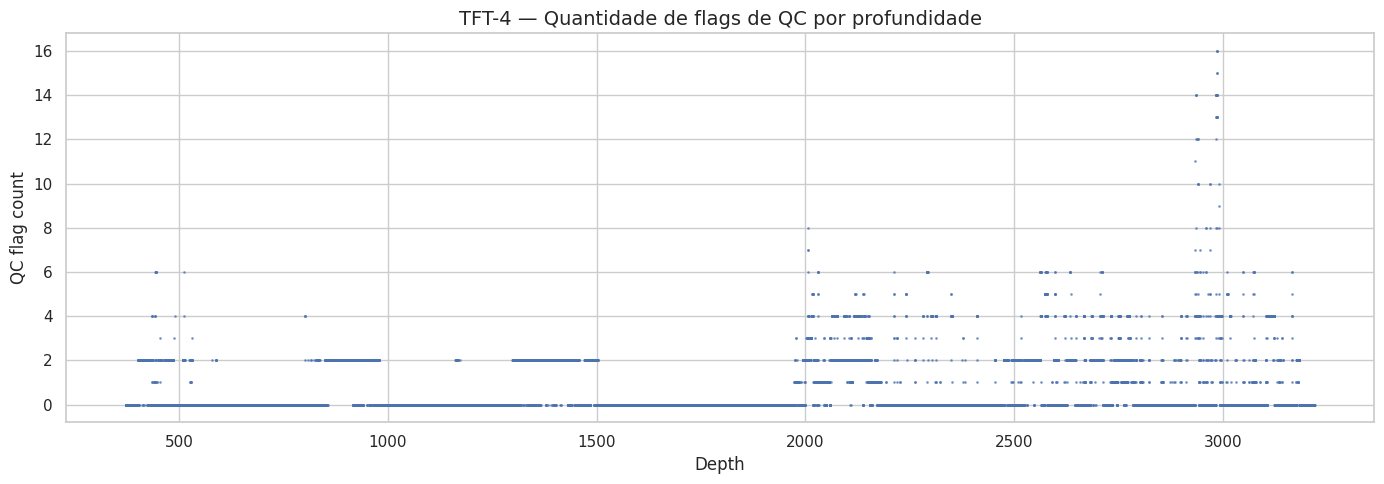

Flags completas salvas em: ../reports/single_well_qc/TFT-4_qc_flags_full.csv


In [24]:
# ============================================================
# STEP 12.1 — SCORE GERAL DE SUSPEITA POR LINHA
# ============================================================

# Vamos criar um score por amostra/profundidade.
# Quanto mais flags verdadeiras uma linha possui, mais suspeita ela é.
#
# Isso ajuda a encontrar intervalos problemáticos.

flag_cols = [c for c in qc_df.columns if c.startswith("FLAG_")]

qc_df["QC_FLAG_COUNT"] = qc_df[flag_cols].sum(axis=1)
qc_df["QC_HAS_ANY_FLAG"] = qc_df["QC_FLAG_COUNT"] > 0

display(
    qc_df.loc[qc_df["QC_HAS_ANY_FLAG"], ["WELL", "DEPTH", "QC_FLAG_COUNT"] + flag_cols]
    .sort_values(["QC_FLAG_COUNT", "DEPTH"], ascending=[False, True])
    .head(100)
)

plt.figure(figsize=(14, 5))
plt.plot(qc_df["DEPTH"], qc_df["QC_FLAG_COUNT"], ".", markersize=2, alpha=0.6)
plt.title(f"{WELL_NAME} — Quantidade de flags de QC por profundidade")
plt.xlabel("Depth")
plt.ylabel("QC flag count")
plt.tight_layout()
plt.show()

qc_flags_path = REPORT_DIR / f"{WELL_NAME}_qc_flags_full.csv"
qc_df[["WELL", "DEPTH", "QC_FLAG_COUNT", "QC_HAS_ANY_FLAG"] + flag_cols].to_csv(qc_flags_path, index=False)
print(f"Flags completas salvas em: {qc_flags_path}")

# STEP 13 — Geological Consistency Check

Agora fazemos checagens de coerência entre curvas.

A ideia aqui é simples:

> Uma curva sozinha pode enganar.  
> Curvas combinadas contam uma história melhor.

Exemplos:
- GR alto costuma indicar mais argila;
- RHOB baixo pode indicar maior porosidade, gás ou problema de poço;
- DTC alto indica velocidade menor, podendo estar ligado a maior porosidade, menor compactação ou gás;
- RDEP alto pode sugerir hidrocarboneto, baixa salinidade, baixa porosidade ou rocha muito resistiva;
- CALI muito maior que BS pode indicar washout, afetando RHOB/NPHI.

Essas regras não são verdades absolutas. São alertas interpretativos.

In [25]:
# ============================================================
# STEP 13 — GEOLOGICAL CONSISTENCY CHECK
# ============================================================

geo_df = qc_df.copy()

# ------------------------------------------------------------
# Indicador de washout:
# CALI - BS muito positivo pode indicar aumento do diâmetro do poço.
# Isso pode prejudicar leituras como RHOB e NPHI.
# ------------------------------------------------------------
if {"CALI", "BS"}.issubset(geo_df.columns):
    geo_df["DCALC"] = geo_df["CALI"] - geo_df["BS"]
    geo_df["FLAG_WASHOUT_DCALC_GT_1IN"] = geo_df["DCALC"].notna() & (geo_df["DCALC"] > 1.0)
else:
    geo_df["DCALC"] = np.nan
    geo_df["FLAG_WASHOUT_DCALC_GT_1IN"] = False


# ------------------------------------------------------------
# Indicador simples de rocha limpa:
# GR baixo pode indicar arenito limpo/carbonato limpo.
# ------------------------------------------------------------
if "GR" in geo_df.columns:
    geo_df["FLAG_CLEAN_ROCK_GR_LOW"] = geo_df["GR"].notna() & (geo_df["GR"] < 50)
    geo_df["FLAG_SHALEY_GR_HIGH"] = geo_df["GR"].notna() & (geo_df["GR"] > 120)
else:
    geo_df["FLAG_CLEAN_ROCK_GR_LOW"] = False
    geo_df["FLAG_SHALEY_GR_HIGH"] = False


# ------------------------------------------------------------
# Possível zona de interesse:
# GR baixo + RDEP alto pode sugerir intervalo limpo e resistivo.
# Isso NÃO prova hidrocarboneto, mas merece investigação.
# ------------------------------------------------------------
if {"GR", "RDEP"}.issubset(geo_df.columns):
    geo_df["FLAG_CLEAN_RESISTIVE_ZONE"] = (
        geo_df["GR"].notna()
        & geo_df["RDEP"].notna()
        & (geo_df["GR"] < 70)
        & (geo_df["RDEP"] > geo_df["RDEP"].quantile(0.75))
    )
else:
    geo_df["FLAG_CLEAN_RESISTIVE_ZONE"] = False


# ------------------------------------------------------------
# Possível problema de densidade afetada por washout:
# RHOB suspeito + washout.
# ------------------------------------------------------------
if "FLAG_RHOB_SUSPICIOUS" in geo_df.columns:
    geo_df["FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT"] = (
        geo_df["FLAG_RHOB_SUSPICIOUS"]
        & geo_df["FLAG_WASHOUT_DCALC_GT_1IN"]
    )
else:
    geo_df["FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT"] = False


# ------------------------------------------------------------
# Possível zona sônica anômala:
# DTC e DTS altos ao mesmo tempo podem indicar baixa velocidade,
# maior porosidade, má qualidade de poço, gás ou formação menos compactada.
# ------------------------------------------------------------
if {"DTC", "DTS"}.issubset(geo_df.columns):
    geo_df["FLAG_HIGH_DTC_HIGH_DTS"] = (
        geo_df["DTC"].notna()
        & geo_df["DTS"].notna()
        & (geo_df["DTC"] > geo_df["DTC"].quantile(0.90))
        & (geo_df["DTS"] > geo_df["DTS"].quantile(0.90))
    )
else:
    geo_df["FLAG_HIGH_DTC_HIGH_DTS"] = False


geo_flag_cols = [
    "FLAG_WASHOUT_DCALC_GT_1IN",
    "FLAG_CLEAN_ROCK_GR_LOW",
    "FLAG_SHALEY_GR_HIGH",
    "FLAG_CLEAN_RESISTIVE_ZONE",
    "FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT",
    "FLAG_HIGH_DTC_HIGH_DTS",
]

geo_summary_df = (
    geo_df[geo_flag_cols]
    .sum()
    .rename("COUNT")
    .to_frame()
)

geo_summary_df["RATE"] = geo_summary_df["COUNT"] / len(geo_df)

display(geo_summary_df)

geo_summary_path = REPORT_DIR / f"{WELL_NAME}_geological_consistency_summary.csv"
geo_summary_df.to_csv(geo_summary_path)
print(f"Resumo geológico salvo em: {geo_summary_path}")

,COUNT,RATE
FLAG_WASHOUT_DCALC_GT_1IN,142,0.007581
FLAG_CLEAN_ROCK_GR_LOW,1303,0.069564
FLAG_SHALEY_GR_HIGH,1139,0.060808
FLAG_CLEAN_RESISTIVE_ZONE,917,0.048956
FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,0,0.000000
FLAG_HIGH_DTC_HIGH_DTS,852,0.045486


Resumo geológico salvo em: ../reports/single_well_qc/TFT-4_geological_consistency_summary.csv


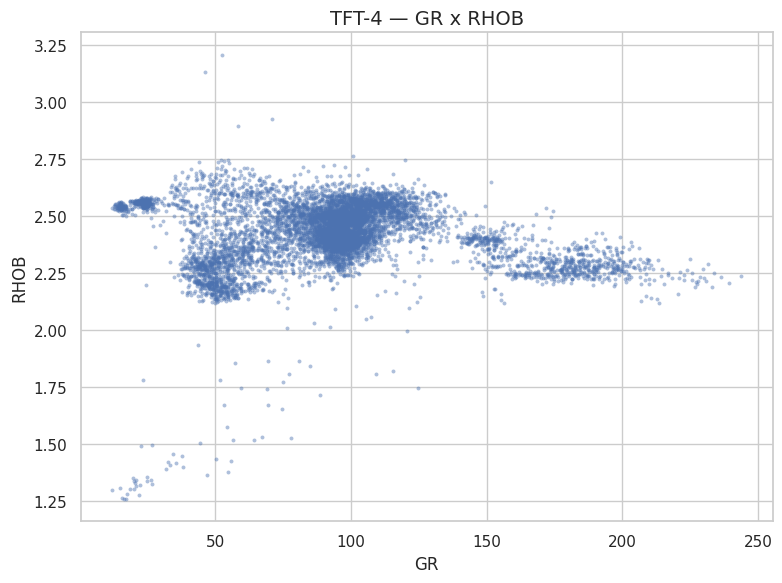

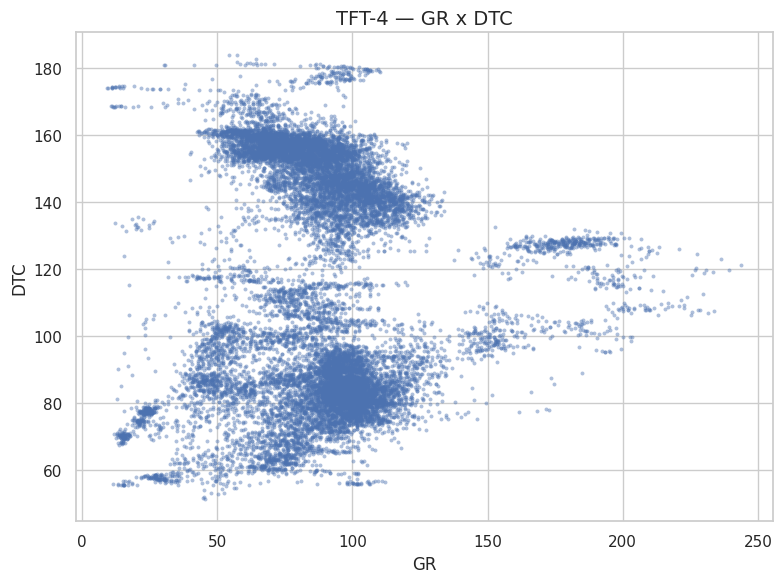

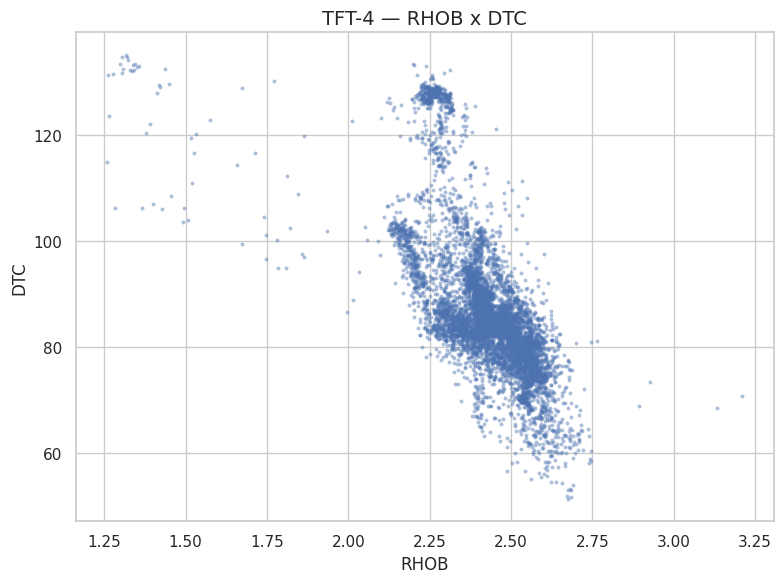

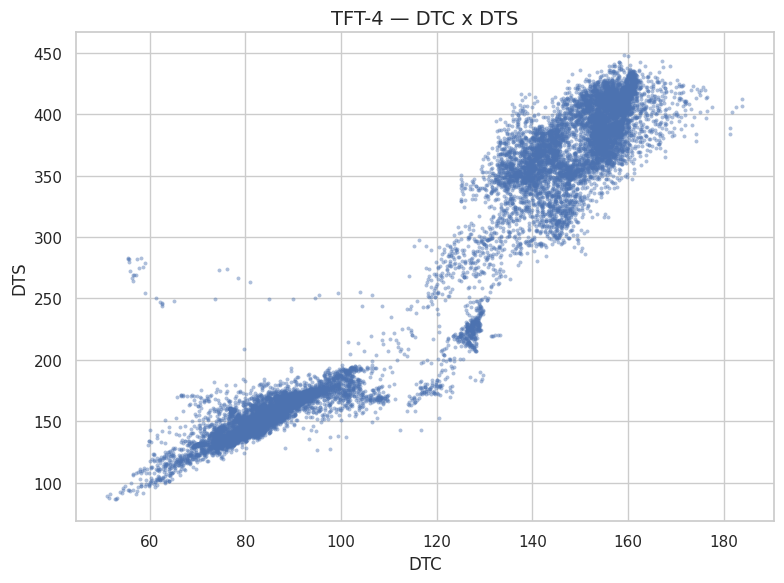

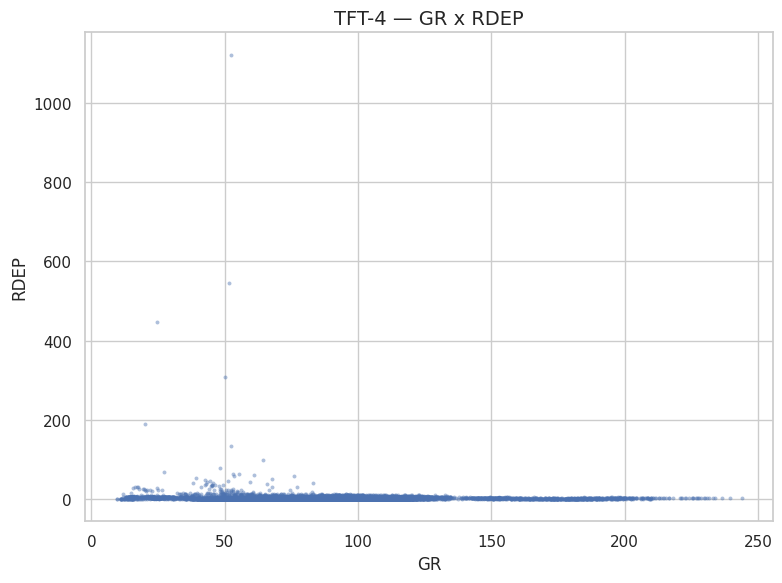

In [26]:
# ============================================================
# STEP 13.1 — CROSSPLOTS GEOLÓGICOS
# ============================================================

def crossplot(df: pd.DataFrame, x: str, y: str, hue: Optional[str] = None, title: Optional[str] = None) -> None:
    """
    Crossplot simples entre duas curvas.

    Crossplots são fundamentais em petrofísica porque mostram relações
    que histograma isolado não mostra.
    """
    if x not in df.columns or y not in df.columns:
        print(f"Crossplot ignorado: {x} ou {y} não existe.")
        return

    cols = [x, y] + ([hue] if hue and hue in df.columns else [])
    plot_df = df[cols].dropna().copy()

    if plot_df.empty:
        print(f"Crossplot sem dados: {x} x {y}")
        return

    # Amostra para não pesar.
    if len(plot_df) > 50_000:
        plot_df = plot_df.sample(50_000, random_state=42)

    plt.figure(figsize=(8, 6))
    if hue and hue in plot_df.columns:
        sns.scatterplot(data=plot_df, x=x, y=y, hue=hue, s=8, alpha=0.45, linewidth=0)
    else:
        sns.scatterplot(data=plot_df, x=x, y=y, s=8, alpha=0.45, linewidth=0)

    plt.title(title or f"{x} x {y}")
    plt.tight_layout()
    plt.show()


crossplot(geo_df, "GR", "RHOB", title=f"{WELL_NAME} — GR x RHOB")
crossplot(geo_df, "GR", "DTC", title=f"{WELL_NAME} — GR x DTC")
crossplot(geo_df, "RHOB", "DTC", title=f"{WELL_NAME} — RHOB x DTC")

if "DTS" in geo_df.columns:
    crossplot(geo_df, "DTC", "DTS", title=f"{WELL_NAME} — DTC x DTS")

if "RDEP" in geo_df.columns:
    crossplot(geo_df, "GR", "RDEP", title=f"{WELL_NAME} — GR x RDEP")

# STEP 14 — Feature Engineering

Agora criamos atributos derivados.

Nesta fase, **não vamos fazer ainda uma interpretação avançada final**.  
Vamos preparar variáveis úteis para analytics e fases futuras.

Atributos principais:

- `VP_MPS`: velocidade compressional a partir de DTC;
- `VS_MPS`: velocidade cisalhante a partir de DTS;
- `RHOB_KG_M3`: densidade em kg/m³;
- `AI`: impedância acústica;
- `SI`: impedância de cisalhamento;
- `VP_VS_RATIO`;
- `POISSON_RATIO`;
- `SHEAR_MODULUS_PA`;
- `BULK_MODULUS_PA`;
- `YOUNG_MODULUS_PA`;
- `VSH_GR_LINEAR`: volume de shale aproximado por GR linear.

Esses atributos são muito importantes para rock physics, geomecânica e futura simulação.

In [27]:
# ============================================================
# STEP 14 — FEATURE ENGINEERING
# ============================================================

features_df = geo_df.copy()

# ------------------------------------------------------------
# Função de conversão DTC/DTS em us/ft para velocidade m/s.
#
# Fórmula:
# velocidade(ft/s) = 1_000_000 / tempo_us_por_ft
# velocidade(m/s)  = velocidade(ft/s) * 0.3048
#
# Portanto:
# v_mps = 304800 / dt_usft
# ------------------------------------------------------------
def sonic_usft_to_mps(dt_usft: pd.Series) -> pd.Series:
    """
    Converte tempo de trânsito sônico em us/ft para velocidade m/s.

    Valores <= 0 são inválidos e viram NaN.
    """
    dt = pd.to_numeric(dt_usft, errors="coerce")
    dt = dt.where(dt > 0)
    return 304_800.0 / dt


if "DTC" in features_df.columns:
    features_df["VP_MPS"] = sonic_usft_to_mps(features_df["DTC"])
else:
    features_df["VP_MPS"] = np.nan


if "DTS" in features_df.columns:
    features_df["VS_MPS"] = sonic_usft_to_mps(features_df["DTS"])
else:
    features_df["VS_MPS"] = np.nan


# ------------------------------------------------------------
# RHOB g/cm3 para kg/m3.
#
# 1 g/cm3 = 1000 kg/m3
# ------------------------------------------------------------
if "RHOB" in features_df.columns:
    features_df["RHOB_KG_M3"] = features_df["RHOB"] * 1000.0
else:
    features_df["RHOB_KG_M3"] = np.nan


# ------------------------------------------------------------
# Impedância acústica:
# AI = rho * Vp
# ------------------------------------------------------------
features_df["AI"] = features_df["RHOB_KG_M3"] * features_df["VP_MPS"]


# ------------------------------------------------------------
# Impedância de cisalhamento:
# SI = rho * Vs
# ------------------------------------------------------------
features_df["SI"] = features_df["RHOB_KG_M3"] * features_df["VS_MPS"]


# ------------------------------------------------------------
# Razão Vp/Vs.
# Muito útil em rock physics.
# ------------------------------------------------------------
features_df["VP_VS_RATIO"] = features_df["VP_MPS"] / features_df["VS_MPS"]


# ------------------------------------------------------------
# Poisson ratio usando Vp e Vs.
#
# nu = (Vp² - 2Vs²) / (2(Vp² - Vs²))
#
# Valores fisicamente comuns ficam aproximadamente entre 0 e 0.5.
# Valores fora disso são suspeitos.
# ------------------------------------------------------------
vp2 = features_df["VP_MPS"] ** 2
vs2 = features_df["VS_MPS"] ** 2

features_df["POISSON_RATIO"] = (vp2 - 2 * vs2) / (2 * (vp2 - vs2))


# ------------------------------------------------------------
# Módulo de cisalhamento:
# G = rho * Vs²
# ------------------------------------------------------------
features_df["SHEAR_MODULUS_PA"] = features_df["RHOB_KG_M3"] * vs2


# ------------------------------------------------------------
# Módulo volumétrico:
# K = rho * (Vp² - 4/3 Vs²)
# ------------------------------------------------------------
features_df["BULK_MODULUS_PA"] = features_df["RHOB_KG_M3"] * (vp2 - (4.0 / 3.0) * vs2)


# ------------------------------------------------------------
# Módulo de Young:
# E = 2G(1 + nu)
# ------------------------------------------------------------
features_df["YOUNG_MODULUS_PA"] = 2 * features_df["SHEAR_MODULUS_PA"] * (1 + features_df["POISSON_RATIO"])


# ------------------------------------------------------------
# Vsh linear por GR.
#
# Vsh = (GR - GR_clean) / (GR_shale - GR_clean)
#
# Aqui usamos percentis do próprio poço como aproximação inicial:
# - GR_clean: P05
# - GR_shale: P95
#
# Isso é uma aproximação inicial, não substitui calibração petrofísica.
# ------------------------------------------------------------
if "GR" in features_df.columns and features_df["GR"].notna().sum() > 10:
    gr_clean = features_df["GR"].quantile(0.05)
    gr_shale = features_df["GR"].quantile(0.95)

    features_df["VSH_GR_LINEAR"] = (
        (features_df["GR"] - gr_clean) / (gr_shale - gr_clean)
    ).clip(lower=0, upper=1)

    print(f"GR clean aproximado P05: {gr_clean:.3f}")
    print(f"GR shale aproximado P95: {gr_shale:.3f}")
else:
    features_df["VSH_GR_LINEAR"] = np.nan


# ------------------------------------------------------------
# Flags físicas dos atributos derivados.
# ------------------------------------------------------------
features_df["FLAG_POISSON_SUSPICIOUS"] = (
    features_df["POISSON_RATIO"].notna()
    & ((features_df["POISSON_RATIO"] < 0) | (features_df["POISSON_RATIO"] > 0.5))
)

features_df["FLAG_VP_VS_SUSPICIOUS"] = (
    features_df["VP_VS_RATIO"].notna()
    & ((features_df["VP_VS_RATIO"] < 1.2) | (features_df["VP_VS_RATIO"] > 3.5))
)

features_df["FLAG_ELASTIC_MODULUS_NEGATIVE"] = (
    (features_df["SHEAR_MODULUS_PA"].notna() & (features_df["SHEAR_MODULUS_PA"] <= 0))
    | (features_df["BULK_MODULUS_PA"].notna() & (features_df["BULK_MODULUS_PA"] <= 0))
    | (features_df["YOUNG_MODULUS_PA"].notna() & (features_df["YOUNG_MODULUS_PA"] <= 0))
)


feature_cols = [
    "VP_MPS", "VS_MPS", "RHOB_KG_M3", "AI", "SI", "VP_VS_RATIO",
    "POISSON_RATIO", "SHEAR_MODULUS_PA", "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA", "VSH_GR_LINEAR"
]

print("Atributos criados:")
display(features_df[["DEPTH"] + feature_cols].describe().T)

GR clean aproximado P05: 45.701
GR shale aproximado P95: 125.441
Atributos criados:


,count,mean,std,min,25%,50%,75%,max
DEPTH,"18,731.000000","1,795.488400",821.912379,372.008400,"1,083.748400","1,795.488400","2,507.228400","3,218.968400"
VP_MPS,"18,199.000000","2,937.276746",903.956624,"1,657.675508","2,053.090733","2,935.564468","3,665.027475","5,951.184603"
VS_MPS,"15,252.000000","1,401.489514",611.703560,679.457190,805.426088,"1,239.633865","1,974.374513","3,518.483947"
RHOB_KG_M3,"7,800.000000","2,423.468666",140.660890,"1,259.570599","2,356.557250","2,432.674170","2,518.348694","3,209.886074"
AI,"7,642.000000","8,733,801.324905","1,556,381.531669","2,926,859.008373","7,975,190.295510","8,784,306.556835","9,635,205.994697","15,928,885.248677"
SI,"7,602.000000","4,820,689.041726","845,084.750142","1,742,690.391854","4,326,002.453885","4,788,368.852272","5,322,273.591022","9,447,535.209436"
VP_VS_RATIO,"15,252.000000",2.166400,0.386320,1.225783,1.809557,2.102940,2.535416,5.084796
POISSON_RATIO,"15,252.000000",0.340246,0.072065,-0.494938,0.280171,0.353902,0.407891,0.479883
SHEAR_MODULUS_PA,"7,602.000000","9,758,011,132.967716","3,111,082,719.000129","2,411,115,188.965303","7,824,359,820.034556","9,436,047,106.087494","11,299,011,931.016850","33,241,000,969.423649"
BULK_MODULUS_PA,"7,602.000000","19,137,770,711.324673","6,242,570,210.571744","1,173,468,737.118097","16,043,230,471.976421","18,976,142,797.645233","21,816,562,912.327908","53,336,996,825.520470"


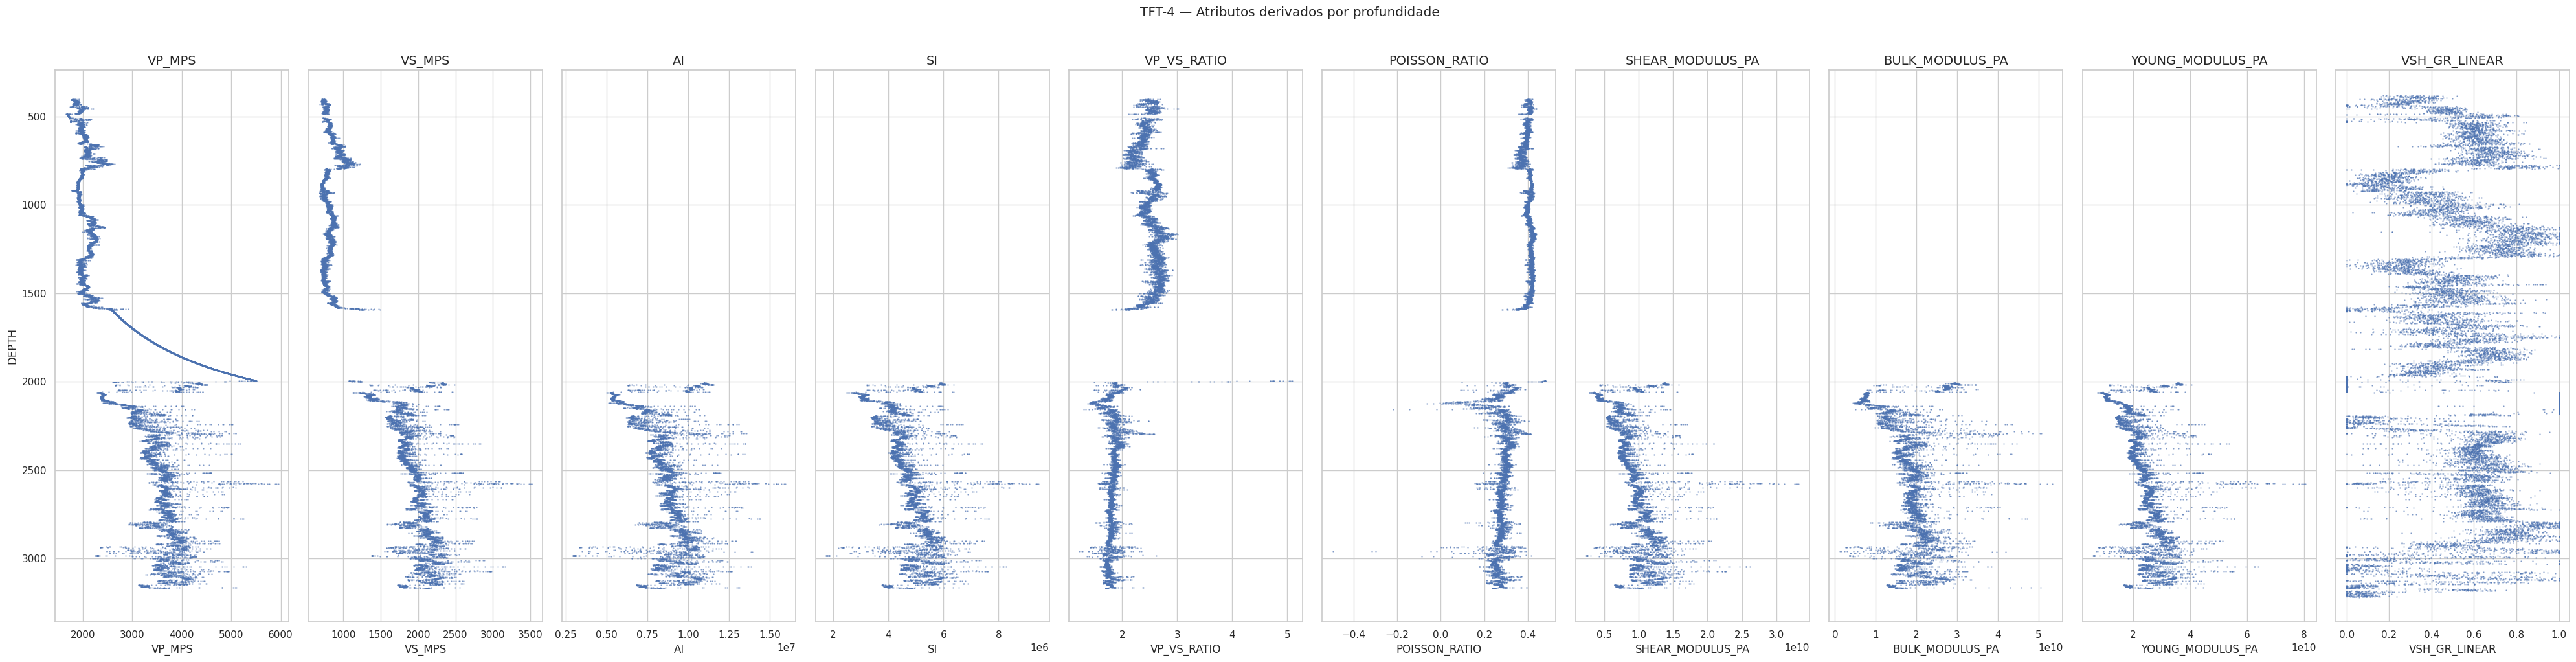

In [28]:
# ============================================================
# STEP 14.1 — VISUALIZAÇÃO DOS ATRIBUTOS DERIVADOS
# ============================================================

derived_curves = [
    "VP_MPS",
    "VS_MPS",
    "AI",
    "SI",
    "VP_VS_RATIO",
    "POISSON_RATIO",
    "SHEAR_MODULUS_PA",
    "BULK_MODULUS_PA",
    "YOUNG_MODULUS_PA",
    "VSH_GR_LINEAR",
]

existing_derived = [c for c in derived_curves if c in features_df.columns]

plot_log_curves(
    features_df,
    "DEPTH",
    existing_derived,
    f"{WELL_NAME} — Atributos derivados por profundidade",
    max_points=30_000,
)

# STEP 15 — Depth Alignment / Resampling

Agora vamos alinhar o dado em uma malha regular de profundidade.

Por que isso importa?

Porque fases futuras como:
- analytics;
- comparação entre poços;
- interpolação;
- FEniCS;
- integração com sísmica;
- ML;

funcionam melhor quando temos uma malha de profundidade controlada.

Estratégia:
- usar o step mediano do poço como referência;
- criar uma grade regular;
- interpolar colunas numéricas;
- preservar o nome do poço;
- manter flags com regra conservadora.

Cuidado:
- interpolar dado ruim gera dado ruim suavizado;
- por isso, esta etapa vem depois do QC.

In [29]:
# ============================================================
# STEP 15 — DEPTH ALIGNMENT / RESAMPLING
# ============================================================

def resample_by_depth(
    df: pd.DataFrame,
    depth_col: str = "DEPTH",
    step: Optional[float] = None,
    max_gap_multiplier: float = 3.0,
) -> pd.DataFrame:
    """
    Reamostra o poço em uma grade regular de profundidade.

    Parâmetros
    ----------
    df:
        DataFrame com DEPTH e curvas.
    depth_col:
        Coluna de profundidade.
    step:
        Step desejado. Se None, usa mediana dos steps positivos.
    max_gap_multiplier:
        Gaps maiores que step * max_gap_multiplier podem indicar buracos.
        Aqui não bloqueamos a interpolação automaticamente, mas criamos uma flag.

    Retorno
    -------
    DataFrame reamostrado em grade regular.
    """
    work = df.copy()
    work = work.dropna(subset=[depth_col])
    work = work.sort_values(depth_col)

    # Remove duplicatas de profundidade por segurança.
    work = work.groupby(depth_col, as_index=False).mean(numeric_only=True)

    depth = work[depth_col]
    diffs = depth.diff()
    positive_diffs = diffs[diffs > 0].dropna()

    if step is None:
        step = positive_diffs.median()

    if pd.isna(step) or step <= 0:
        raise ValueError("Step inválido para resampling.")

    depth_min = depth.min()
    depth_max = depth.max()

    # Cria grade regular.
    new_depth = np.arange(depth_min, depth_max + step, step)

    # Coloca DEPTH como índice para interpolação.
    indexed = work.set_index(depth_col)

    # Reindexa para grade nova.
    # Como profundidade é float, usamos union para preservar pontos originais,
    # interpolamos e depois selecionamos apenas a grade final.
    full_index = indexed.index.union(pd.Index(new_depth, name=depth_col)).sort_values()
    aligned = indexed.reindex(full_index)

    # Interpolação por índice.
    aligned = aligned.interpolate(method="index", limit_direction="both")

    # Seleciona apenas a grade regular.
    resampled = aligned.loc[new_depth].reset_index()
    resampled = resampled.rename(columns={"index": depth_col})

    # Flag de gaps no dado original.
    gap_threshold = step * max_gap_multiplier
    gap_intervals = pd.DataFrame({
        "START_DEPTH": depth.shift(1),
        "END_DEPTH": depth,
        "GAP_SIZE": diffs,
    }).dropna()

    gap_intervals = gap_intervals[gap_intervals["GAP_SIZE"] > gap_threshold].copy()

    resampled["FLAG_INTERPOLATED_ACROSS_LARGE_GAP"] = False

    # Este loop aqui é pequeno e interpretativo.
    # O grosso do trabalho pesado continua vetorizado com pandas/numpy.
    for _, row in gap_intervals.iterrows():
        mask = (resampled[depth_col] > row["START_DEPTH"]) & (resampled[depth_col] < row["END_DEPTH"])
        resampled.loc[mask, "FLAG_INTERPOLATED_ACROSS_LARGE_GAP"] = True

    resampled["WELL"] = WELL_NAME
    resampled["RESAMPLE_STEP"] = step

    return resampled


resampled_df = resample_by_depth(features_df, "DEPTH", step=None)

print(f"Shape antes do resampling:  {features_df.shape}")
print(f"Shape depois do resampling: {resampled_df.shape}")
print(f"Step usado: {resampled_df['RESAMPLE_STEP'].iloc[0]}")

display(resampled_df.head())
display(resampled_df.tail())

Shape antes do resampling:  (18731, 106)
Shape depois do resampling: (18731, 108)
Step usado: 0.15200000000004366


/tmp/ipykernel_2083414/1042843649.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resampled = aligned.loc[new_depth].reset_index()
/tmp/ipykernel_2083414/1042843649.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resampled["FLAG_INTERPOLATED_ACROSS_LARGE_GAP"] = False
/tmp/ipykernel_2083414/1042843649.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

,DEPTH,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,DCALC,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS,VP_MPS,VS_MPS,RHOB_KG_M3,AI,SI,VP_VS_RATIO,POISSON_RATIO,SHEAR_MODULUS_PA,BULK_MODULUS_PA,YOUNG_MODULUS_PA,VSH_GR_LINEAR,FLAG_POISSON_SUSPICIOUS,FLAG_VP_VS_SUSPICIOUS,FLAG_ELASTIC_MODULUS_NEGATIVE,FLAG_INTERPOLATED_ACROSS_LARGE_GAP,WELL,RESAMPLE_STEP
0,372.008400,1.000000,"70,000.000000",12.473659,9.875000,271.724701,23.083862,0.643297,0.658484,424.432648,158.085037,0.120854,5.286586,60.607098,2.521080,0.116540,"525,290.062500","6,759,850.000000",-348.912415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.486433,0.000000,0.725342,0.000000,1.252361,0.000000,1.157087,0.000000,-2.672823,0.000000,-0.683005,0.000000,-0.652843,0.000000,41.894902,0.000000,0.000000,0.000000,0.000000,0.000000,0.223658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"1,928.076214",718.135143,"2,521.079779","10,963,881.416928","5,860,145.089638",2.684838,0.419463,"13,621,663,527.570845","29,518,421,322.630413","35,417,095,784.742775",0.186938,0.000000,0.000000,0.000000,False,TFT-4,0.152000
1,372.160400,1.000000,"70,000.000000",12.473659,9.875000,271.724701,23.083862,0.643297,0.658484,424.432648,158.085037,0.120854,5.286586,60.607098,2.521080,0.116540,"525,290.062500","6,759,850.000000",-348.912415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.486433,0.000000,0.725342,0.000000,1.252361,0.000000,1.157087,0.000000,-2.672823,0.000000,-0.683005,0.000000,-0.652843,0.000000,41.894902,0.000000,0.000000,0.000000,0.000000,0.000000,0.223658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"1,928.076214",718.135143,"2,521.079779","10,963,881.416928","5,860,145.089638",2.684838,0.419463,"13,621,663,527.570845","29,518,421,322.630413","35,417,095,784.742775",0.186938,0.000000,0.000000,0.000000,False,TFT-4,0.152000
2,372.312400,1.000000,"70,000.000000",12.473659,9.875000,271.724701,23.083862,0.643297,0.658484,424.432648,158.085037,0.120854,5.286586,60.607098,2.

,DEPTH,LITHOLOGY_CONFIDENCE,LITHOLOGY_CLASS,CALI,BS,ROPA,ROP,RDEP,RMED,DTS,DTC,NPOR,PEF,GR,RHOB,DRHO,X_LOC,Y_LOC,Z_LOC,FLAG_GR_LOW,FLAG_GR_HIGH,FLAG_GR_ZERO,FLAG_GR_SUSPICIOUS,FLAG_RHOB_LOW,FLAG_RHOB_HIGH,FLAG_RHOB_ZERO,FLAG_RHOB_SUSPICIOUS,FLAG_DTC_LOW,FLAG_DTC_HIGH,FLAG_DTC_ZERO,FLAG_DTC_SUSPICIOUS,FLAG_DTS_LOW,FLAG_DTS_HIGH,FLAG_DTS_ZERO,FLAG_DTS_SUSPICIOUS,FLAG_NPOR_LOW,FLAG_NPOR_HIGH,FLAG_NPOR_ZERO,FLAG_NPOR_SUSPICIOUS,FLAG_RDEP_LOW,FLAG_RDEP_HIGH,FLAG_RDEP_ZERO,FLAG_RDEP_SUSPICIOUS,FLAG_RMED_LOW,FLAG_RMED_HIGH,FLAG_RMED_ZERO,FLAG_RMED_SUSPICIOUS,FLAG_CALI_LOW,FLAG_CALI_HIGH,FLAG_CALI_ZERO,FLAG_CALI_SUSPICIOUS,FLAG_BS_LOW,FLAG_BS_HIGH,FLAG_BS_ZERO,FLAG_BS_SUSPICIOUS,FLAG_GR_IQR_OUTLIER,FLAG_RHOB_IQR_OUTLIER,FLAG_DTC_IQR_OUTLIER,FLAG_DTS_IQR_OUTLIER,FLAG_NPOR_IQR_OUTLIER,FLAG_RDEP_IQR_OUTLIER,FLAG_RMED_IQR_OUTLIER,FLAG_CALI_IQR_OUTLIER,FLAG_BS_IQR_OUTLIER,ROBUST_Z_GR,FLAG_GR_ROBUST_Z_OUTLIER,ROBUST_Z_RHOB,FLAG_RHOB_ROBUST_Z_OUTLIER,ROBUST_Z_DTC,FLAG_DTC_ROBUST_Z_OUTLIER,ROBUST_Z_DTS,FLAG_DTS_ROBUST_Z_OUTLIER,ROBUST_Z_NPOR,FLAG_NPOR_ROBUST_Z_OUTLIER,ROBUST_Z_RDEP,FLAG_RDEP_ROBUST_Z_OUTLIER,ROBUST_Z_RMED,FLAG_RMED_ROBUST_Z_OUTLIER,ROBUST_Z_CALI,FLAG_CALI_ROBUST_Z_OUTLIER,ROBUST_Z_BS,FLAG_BS_ROBUST_Z_OUTLIER,QC_FLAG_COUNT,QC_HAS_ANY_FLAG,DCALC,FLAG_WASHOUT_DCALC_GT_1IN,FLAG_CLEAN_ROCK_GR_LOW,FLAG_SHALEY_GR_HIGH,FLAG_CLEAN_RESISTIVE_ZONE,FLAG_RHOB_SUSPICIOUS_WITH_WASHOUT,FLAG_HIGH_DTC_HIGH_DTS,VP_MPS,VS_MPS,RHOB_KG_M3,AI,SI,VP_VS_RATIO,POISSON_RATIO,SHEAR_MODULUS_PA,BULK_MODULUS_PA,YOUNG_MODULUS_PA,VSH_GR_LINEAR,FLAG_POISSON_SUSPICIOUS,FLAG_VP_VS_SUSPICIOUS,FLAG_ELASTIC_MODULUS_NEGATIVE,FLAG_INTERPOLATED_ACROSS_LARGE_GAP,WELL,RESAMPLE_STEP
18726,"3,218.360400",1.000000,"30,000.000000",8.484615,8.500000,32.203064,31.134609,1.111613,1.068531,140.646774,81.411461,0.268813,2.212700,50.487297,2.253233,0.044930,"524,869.937500","6,760,192.500000","-2,964.480713",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.998444,0.000000,-1.472263,0.000000,-0.517487,0.000000,-0.681941,0.000000,-0.332979,0.000000,-0.276096,0.000000,-0.294376,0.000000,-0.555050,0.000000,-0.674500,0.000000,0.000000,0.000000,-0.015385,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"3,743.944608","2,167.131109","2,253.232956","8,522,018.699822","4,932,853.920521",1.727604,0.248062,"10,690,141,189.266047","17,652,444,377.288128","26,683,919,867.595406",0.060028,0.000000,0.000000,0.000000,False,TFT-4,0.152000
18727,"3,218.512400",1.000000,"30,000.000000",8.484615,8.500000,28.998888,31.134609,1.111613,1.068531,140.646774,81.411461,0.268813,2.212700,50.487297,2.253233,0.044930,"524,869.937500","6,760,192.500000","-2,964.480713",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.998444,0.000000,-1.472263,0.000000,-0.517487,0.000000,-0.681941,0.000000,-0.332979,0.000000,-0.276096,0.000000,-0.294376,0.000000,-0.555050,0.000000,-0.674500,0.000000,0.000000,0.000000,-0.015385,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"3,743.944608","2,167.131109","2,253.232956","8,522,018.699822","4,932,853.920521",1.727604,0.248062,"10,690,141,189.266047","17,652,444,377.288128","26,683,919,867.595406",0.060028,0.000000,0.000000,0.000000,False,TFT-4,0.152000
18728,"3,218.664400",1.000000,"30,000.000000",8.484615,8.500000,25.799675,31.134609,1.111613,1.068531,140.646774,8

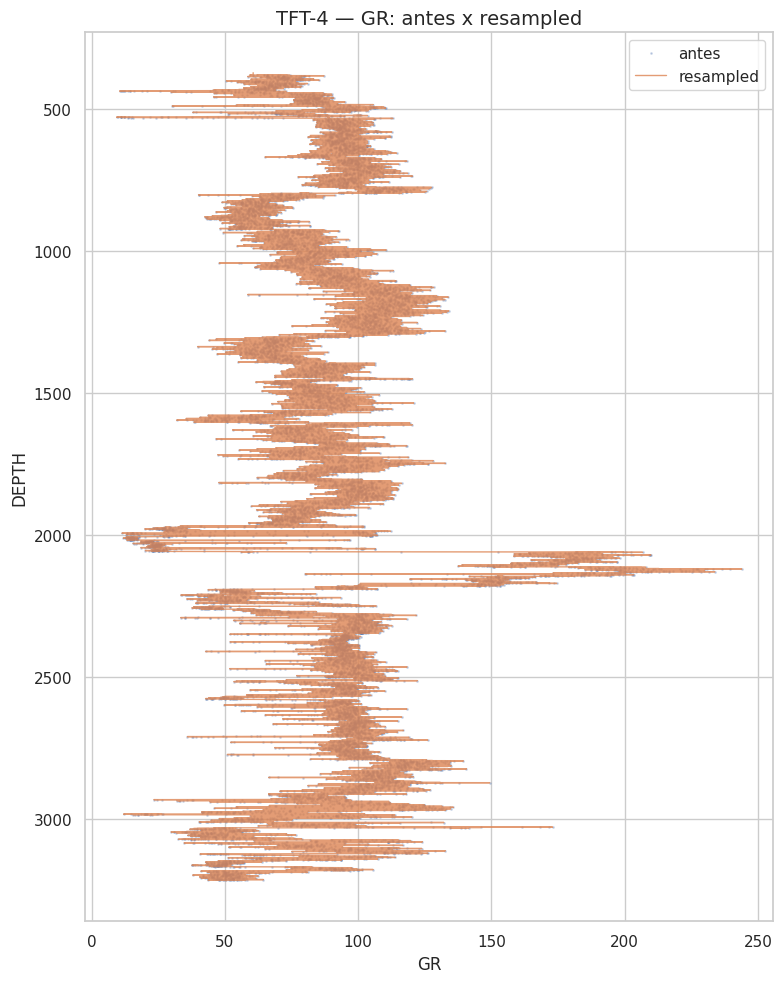

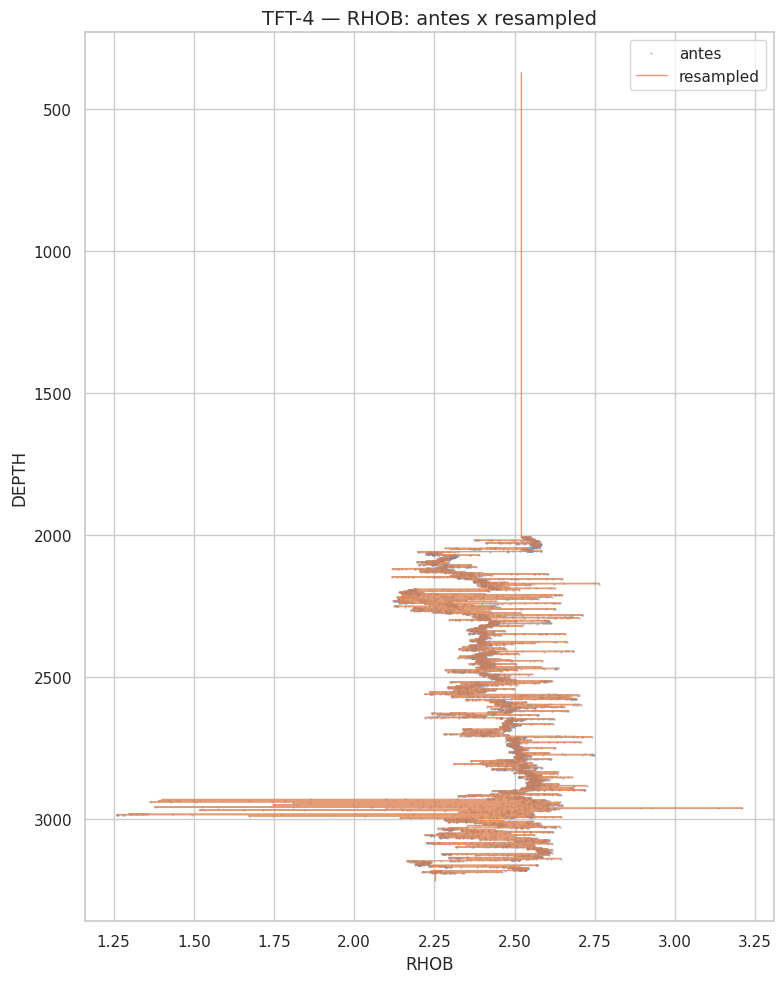

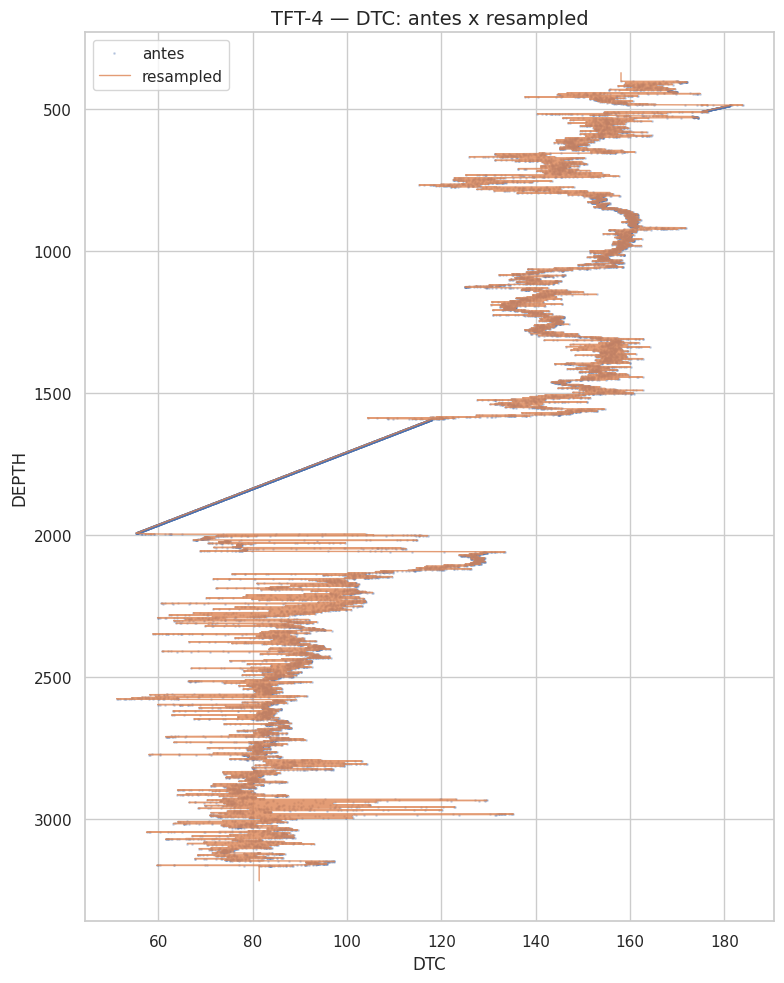

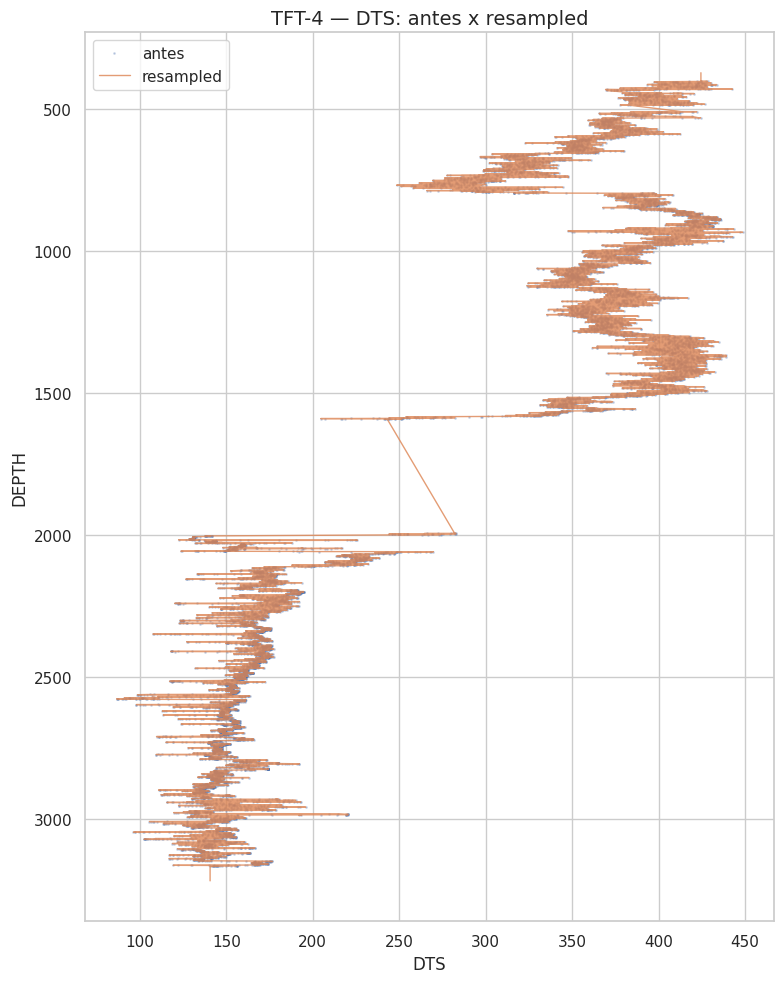

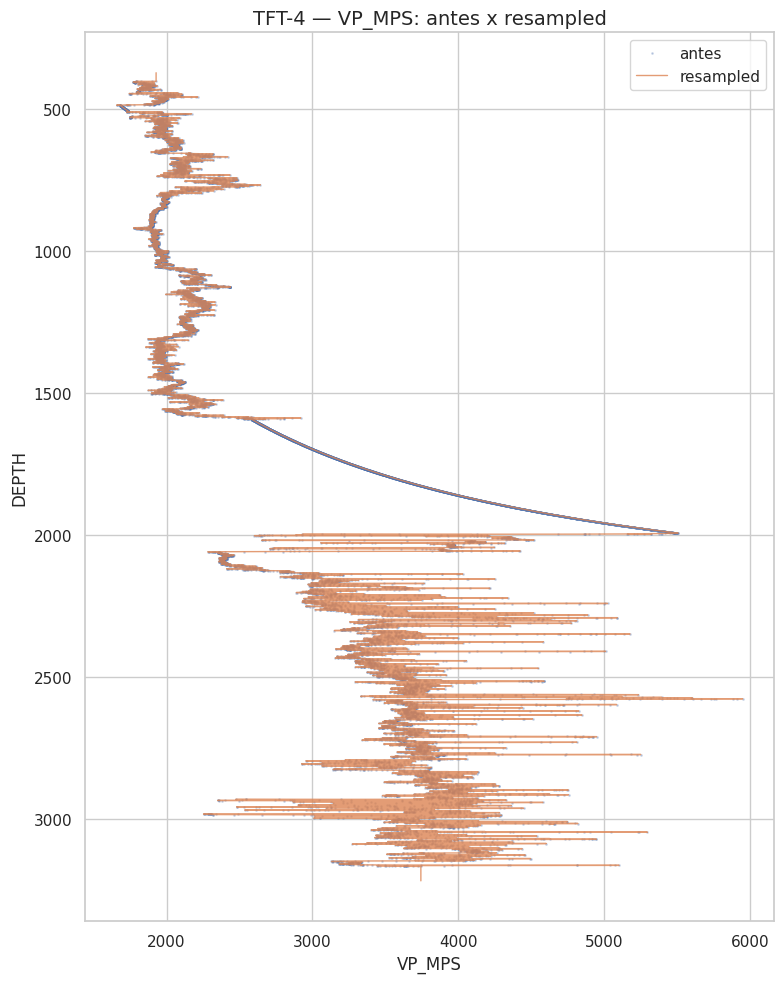

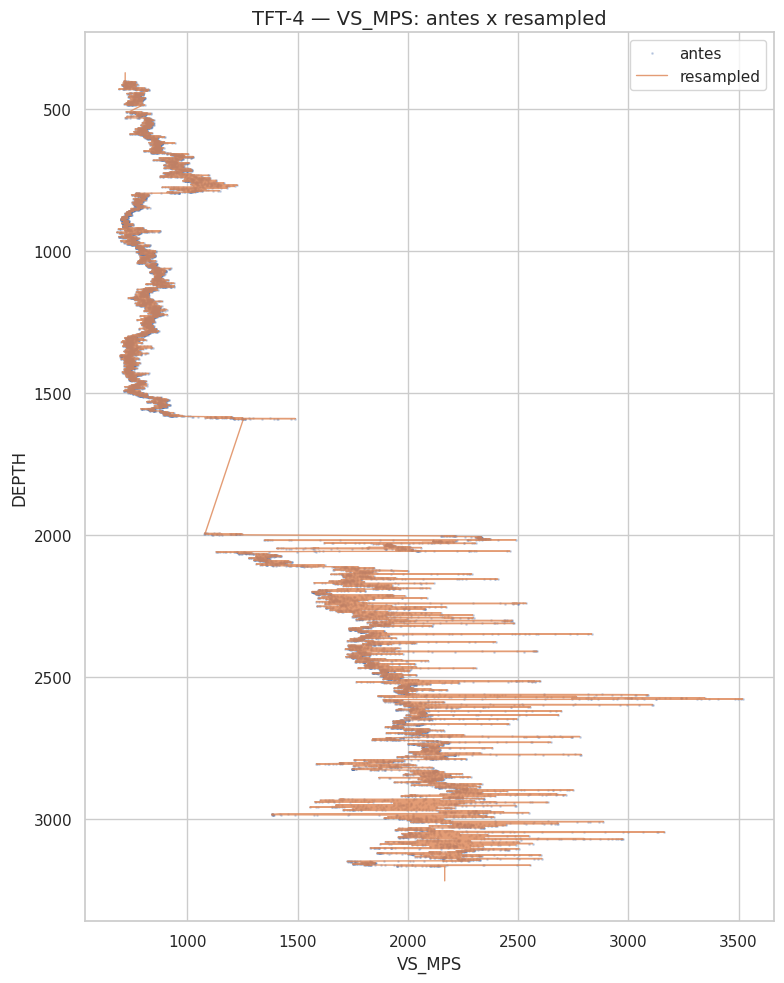

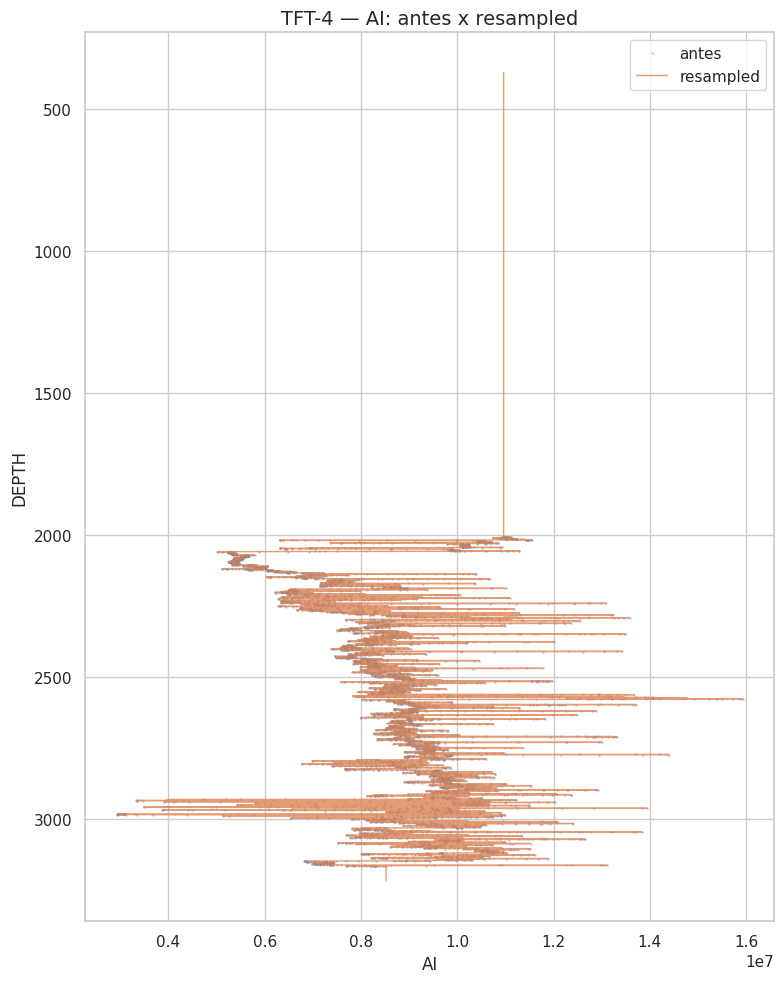

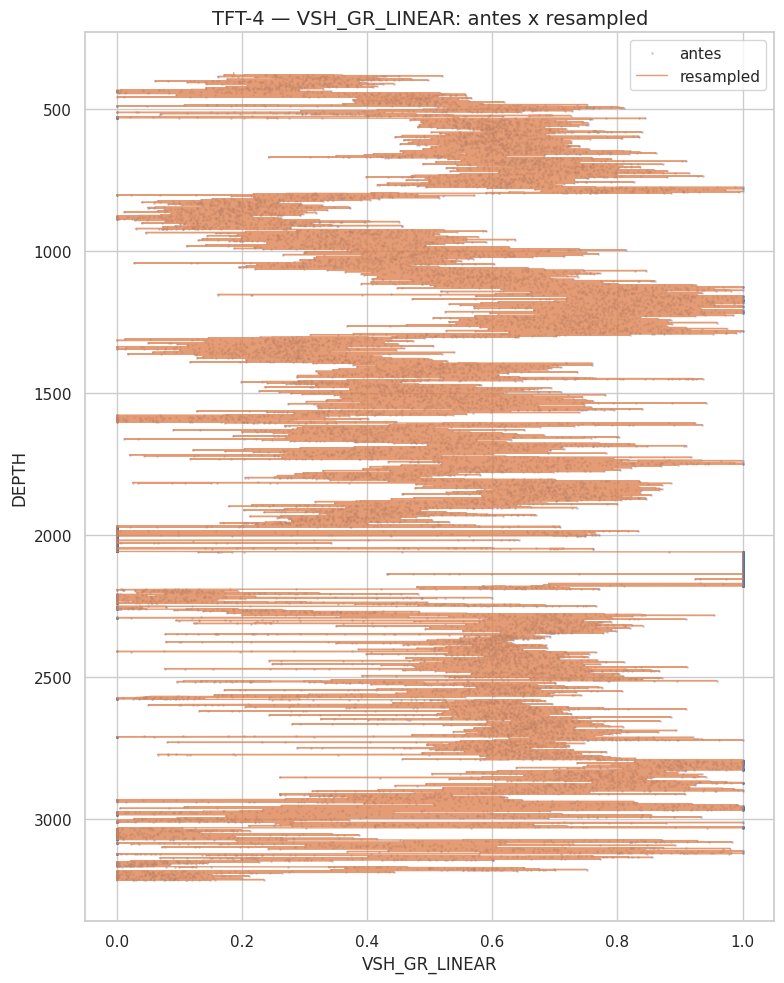

In [30]:
# ============================================================
# STEP 15.1 — COMPARAÇÃO ANTES E DEPOIS DO RESAMPLING
# ============================================================

compare_curves = [c for c in ["GR", "RHOB", "DTC", "DTS", "VP_MPS", "VS_MPS", "AI", "VSH_GR_LINEAR"] if c in features_df.columns]

for curve in compare_curves:
    plt.figure(figsize=(8, 10))

    raw_plot = features_df[["DEPTH", curve]].dropna()
    res_plot = resampled_df[["DEPTH", curve]].dropna()

    if len(raw_plot) > 30_000:
        raw_plot = raw_plot.sample(30_000, random_state=42).sort_values("DEPTH")

    plt.plot(raw_plot[curve], raw_plot["DEPTH"], ".", markersize=2, alpha=0.25, label="antes")
    plt.plot(res_plot[curve], res_plot["DEPTH"], "-", linewidth=1, alpha=0.8, label="resampled")

    plt.gca().invert_yaxis()
    plt.title(f"{WELL_NAME} — {curve}: antes x resampled")
    plt.xlabel(curve)
    plt.ylabel("DEPTH")
    plt.legend()
    plt.tight_layout()
    plt.show()

# STEP 16 — Export to Parquet

Agora exportamos o dataset final.

A ideia é separar claramente:

- **LAS bruto**: fonte original, intocada;
- **CSV de relatórios**: auditoria do QC;
- **Parquet processado**: dataset limpo/padronizado/pronto para analytics.

O Parquet é excelente porque:
- é colunar;
- é compacto;
- funciona muito bem com pandas, DuckDB, Polars, Spark;
- preserva tipos melhor que CSV;
- é ótimo para pipelines analíticos.

Vamos salvar:
1. Parquet final com dados reamostrados;
2. Parquet pré-resampling, caso você queira comparar;
3. CSV de dicionário de colunas;
4. CSV de resumo final.

In [31]:
# ============================================================
# STEP 16 — EXPORT TO PARQUET
# ============================================================

# ------------------------------------------------------------
# Organização final das colunas
# ------------------------------------------------------------
preferred_order = [
    "WELL",
    "DEPTH",
    "RESAMPLE_STEP",

    # Curvas originais principais
    "GR", "RHOB", "DTC", "DTS", "NPOR",
    "RDEP", "RMED", "RSHA", "CALI", "BS",

    # Curvas/atributos auxiliares
    "DCALC",
    "VP_MPS", "VS_MPS", "RHOB_KG_M3",
    "AI", "SI", "VP_VS_RATIO", "POISSON_RATIO",
    "SHEAR_MODULUS_PA", "BULK_MODULUS_PA", "YOUNG_MODULUS_PA",
    "VSH_GR_LINEAR",
]

existing_preferred = [c for c in preferred_order if c in resampled_df.columns]
remaining_cols = [c for c in resampled_df.columns if c not in existing_preferred]

final_df = resampled_df[existing_preferred + remaining_cols].copy()


# ------------------------------------------------------------
# Otimização leve de tipos
# ------------------------------------------------------------
# Mantemos WELL como string.
# Colunas booleanas como bool.
# Numéricas como float64 por segurança científica.
# Em produção, poderíamos usar float32 se tamanho fosse prioridade.
# ------------------------------------------------------------
if "WELL" in final_df.columns:
    final_df["WELL"] = final_df["WELL"].astype("string")

bool_cols = [c for c in final_df.columns if c.startswith("FLAG_") or final_df[c].dtype == bool]
for col in bool_cols:
    final_df[col] = final_df[col].fillna(False).astype(bool)


# ------------------------------------------------------------
# Export Parquet
# ------------------------------------------------------------
safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

parquet_final_path = OUTPUT_DIR / f"{safe_well_name}_single_well_qc_features_resampled.parquet"
parquet_pre_resample_path = OUTPUT_DIR / f"{safe_well_name}_single_well_qc_features_pre_resample.parquet"

final_df.to_parquet(parquet_final_path, index=False)
features_df.to_parquet(parquet_pre_resample_path, index=False)


# ------------------------------------------------------------
# Dicionário de colunas
# ------------------------------------------------------------
column_dictionary_rows = []

for col in final_df.columns:
    if col in PHYSICAL_RULES:
        meaning = PHYSICAL_RULES[col]["description"]
    elif col == "VP_MPS":
        meaning = "Compressional velocity derived from DTC"
    elif col == "VS_MPS":
        meaning = "Shear velocity derived from DTS"
    elif col == "AI":
        meaning = "Acoustic impedance = density * Vp"
    elif col == "SI":
        meaning = "Shear impedance = density * Vs"
    elif col == "VP_VS_RATIO":
        meaning = "Vp/Vs ratio"
    elif col == "POISSON_RATIO":
        meaning = "Poisson ratio derived from Vp and Vs"
    elif col == "SHEAR_MODULUS_PA":
        meaning = "Shear modulus G = rho * Vs^2"
    elif col == "BULK_MODULUS_PA":
        meaning = "Bulk modulus K = rho * (Vp^2 - 4/3 Vs^2)"
    elif col == "YOUNG_MODULUS_PA":
        meaning = "Young modulus E = 2G(1+nu)"
    elif col == "VSH_GR_LINEAR":
        meaning = "Linear shale volume approximation from GR percentiles"
    elif col.startswith("FLAG_"):
        meaning = "QC / geological / physical flag"
    else:
        meaning = "Original or intermediate curve/attribute"

    column_dictionary_rows.append({
        "COLUMN": col,
        "DTYPE": str(final_df[col].dtype),
        "NON_NULL_COUNT": final_df[col].notna().sum(),
        "NULL_COUNT": final_df[col].isna().sum(),
        "FILL_RATE": final_df[col].notna().mean(),
        "MEANING": meaning,
    })

column_dictionary_df = pd.DataFrame(column_dictionary_rows)

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_final_column_dictionary.csv"
column_dictionary_df.to_csv(column_dictionary_path, index=False)


# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------
final_summary = {
    "WELL": WELL_NAME,
    "SOURCE_FILE": selected_file.name,
    "FINAL_ROWS": len(final_df),
    "FINAL_COLUMNS": final_df.shape[1],
    "DEPTH_MIN": final_df["DEPTH"].min(),
    "DEPTH_MAX": final_df["DEPTH"].max(),
    "RESAMPLE_STEP": final_df["RESAMPLE_STEP"].iloc[0] if "RESAMPLE_STEP" in final_df.columns else np.nan,
    "HAS_DTC": "DTC" in final_df.columns and final_df["DTC"].notna().any(),
    "HAS_DTS": "DTS" in final_df.columns and final_df["DTS"].notna().any(),
    "HAS_RHOB": "RHOB" in final_df.columns and final_df["RHOB"].notna().any(),
    "HAS_GR": "GR" in final_df.columns and final_df["GR"].notna().any(),
    "PARQUET_FINAL": str(parquet_final_path),
    "PARQUET_PRE_RESAMPLE": str(parquet_pre_resample_path),
}

final_summary_df = pd.DataFrame([final_summary])

final_summary_path = REPORT_DIR / f"{safe_well_name}_final_summary.csv"
final_summary_df.to_csv(final_summary_path, index=False)


print("EXPORTAÇÃO CONCLUÍDA COM SUCESSO!")
print(f"Parquet final:          {parquet_final_path}")
print(f"Parquet pré-resampling: {parquet_pre_resample_path}")
print(f"Dicionário de colunas:  {column_dictionary_path}")
print(f"Resumo final:           {final_summary_path}")

display(final_summary_df)
display(column_dictionary_df)

EXPORTAÇÃO CONCLUÍDA COM SUCESSO!
Parquet final:          ../data/parquet/processed/TFT-4_single_well_qc_features_resampled.parquet
Parquet pré-resampling: ../data/parquet/processed/TFT-4_single_well_qc_features_pre_resample.parquet
Dicionário de colunas:  ../reports/single_well_qc/TFT-4_final_column_dictionary.csv
Resumo final:           ../reports/single_well_qc/TFT-4_final_summary.csv


,WELL,SOURCE_FILE,FINAL_ROWS,FINAL_COLUMNS,DEPTH_MIN,DEPTH_MAX,RESAMPLE_STEP,HAS_DTC,HAS_DTS,HAS_RHOB,HAS_GR,PARQUET_FINAL,PARQUET_PRE_RESAMPLE
0,TFT-4,TFT-4.las,18731,108,372.008400,"3,218.968400",0.152000,True,True,True,True,../data/parquet/processed/TFT-4_single_well_qc...,../data/parquet/processed/TFT-4_single_well_qc...


,COLUMN,DTYPE,NON_NULL_COUNT,NULL_COUNT,FILL_RATE,MEANING
0,WELL,string,18731,0,1.000000,Original or intermediate curve/attribute
1,DEPTH,float64,18731,0,1.000000,Original or intermediate curve/attribute
2,RESAMPLE_STEP,float64,18731,0,1.000000,Original or intermediate curve/attribute
3,GR,float64,18731,0,1.000000,Gamma Ray
4,RHOB,float64,18731,0,1.000000,Bulk Density
5,DTC,float64,18731,0,1.000000,Compressional Sonic
6,DTS,float64,18731,0,1.000000,Shear Sonic
7,NPOR,float64,18731,0,1.000000,Neutron Porosity
8,RDEP,float64,18731,0,1.000000,Deep Resistivity
9,RMED,float64,18731,0,1.000000,Medium Resistivity


# Encerramento da fase 1–16

Neste ponto, o pipeline entregou:

- um poço selecionado;
- metadata auditada;
- inventário de curvas;
- QC de profundidade;
- QC de unidades;
- análise de nulos;
- tratamento de placeholders inválidos;
- duplicatas tratadas;
- flags físicas;
- investigação estatística de outliers;
- checagens geológicas simples;
- atributos derivados;
- resampling por profundidade;
- exportação em Parquet.

## Próxima fase futura

Depois deste notebook, o caminho natural é:

1. abrir o Parquet com pandas ou DuckDB;
2. fazer analytics profundo;
3. estudar intervalos específicos;
4. selecionar zonas;
5. aprofundar rock physics;
6. preparar propriedades para FEniCS;
7. modelar elasticidade, poroelasticidade e termoporoelasticidade.

## Lembrete importante

Este notebook é um pipeline técnico e científico.  
Ele não substitui interpretação petrofísica profissional, mas cria uma base muito mais confiável para ela.